In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

# Machine Learning - Models
from sklearn.ensemble import RandomForestClassifier, IsolationForest, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Machine Learning - Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

print("All libraries imported successfully!")

All libraries imported successfully!


# =====================================================================

# Data Exploration - Dataset 2024-2025

# =====================================================================


This section presents an in-depth exploratory analysis of the 5G dataset for years 2024-2025.

## 1. Data Loading

In [2]:
# Batch configuration
from pathlib import Path

DATASET_PATH = Path('5g_anomaly_dataset_2024_2025.csv')
USE_BATCH_MODE = True
BATCH_SIZE = 50000
BATCH_NUMBER = 1  # 1 = first batch, 2 = second batch, ...

print('Batch configuration ready.')
print(f'  Dataset path : {DATASET_PATH}')
print(f'  Batch mode   : {USE_BATCH_MODE}')
if USE_BATCH_MODE:
    print(f'  Batch size   : {BATCH_SIZE:,}')
    print(f'  Batch number : {BATCH_NUMBER}')

Batch configuration ready.
  Dataset path : 5g_anomaly_dataset_2024_2025.csv
  Batch mode   : True
  Batch size   : 50,000
  Batch number : 1


In [3]:
# Load the dataset or a specific batch
if USE_BATCH_MODE:
    total_rows = sum(1 for _ in DATASET_PATH.open('r', encoding='utf-8')) - 1
    start_row = (BATCH_NUMBER - 1) * BATCH_SIZE

    if start_row >= total_rows:
        raise ValueError(
            f'Batch {BATCH_NUMBER} is out of range. Dataset has {total_rows:,} data rows.'
        )

    rows_to_read = min(BATCH_SIZE, total_rows - start_row)
    df = pd.read_csv(DATASET_PATH, skiprows=range(1, start_row + 1), nrows=rows_to_read)
else:
    total_rows = sum(1 for _ in DATASET_PATH.open('r', encoding='utf-8')) - 1
    start_row = 0
    rows_to_read = total_rows
    df = pd.read_csv(DATASET_PATH)

# Convert timestamp column to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

print('✅ Dataset loaded successfully!')
print(f'📊 Loaded dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'📅 Period covered: {df["timestamp"].min()} to {df["timestamp"].max()}')
if USE_BATCH_MODE:
    print(f'📦 Active batch: {BATCH_NUMBER} | Rows loaded: {start_row:,} to {start_row + len(df) - 1:,}')
else:
    print(f'📚 Full dataset loaded: {total_rows:,} rows')

✅ Dataset loaded successfully!
📊 Loaded dimensions: 50,000 rows × 22 columns
📅 Period covered: 2024-01-01 00:04:46 to 2024-06-22 14:40:22
📦 Active batch: 1 | Rows loaded: 0 to 49,999


## 2. Data Overview

In [4]:
# Display first rows
print(" First rows of the dataset:")
df.head(10)

 First rows of the dataset:


,timestamp,cell_id,ue_id,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,rtt_ms,packet_delay_budget_ms,handover_interruption_time_ms,reliability_percent,packet_loss_percent,packet_loss_rate_percent,bler_percent,throughput_dl_mbps,throughput_ul_mbps,spectral_efficiency_bps_hz,handover_success_rate_percent,energy_efficiency_bits_per_joule,anomaly,anomaly_type
0,2024-01-01 00:04:46,gNB-042,UE-3CD99EBD,eMBB,33.852372,-7.432579,6.5374,5.6247,21.9347,72.3138,24.1853,99.6704,0.282045,0.566823,4.045900,8838.0518,5886.2035,17.4116,99.4285,51054585.0,0,normal
1,2024-01-01 00:10:25,gNB-044,UE-38EC20B2,URLLC,34.091446,-7.549245,2.9853,0.7240,1.9772,0.6080,4.4692,99.9996,0.000878,0.000413,0.206868,41.8399,88.1483,13.1571,99.1853,427078719.0,0,normal
2,2024-01-01 00:15:06,gNB-047,UE-3F7C8DB8,eMBB,33.977857,-7.571867,10.2100,7.0577,30.3852,61.2198,31.1128,99.5963,0.431412,0.300520,7.398000,4906.4537,3563.4036,21.7581,99.6506,75943423.0,0,normal
3,2024-01-01 00:20:12,gNB-022,UE-DCF759D2,URLLC,33.632320,-7.612415,3.6215,0.5090,5.2518,0.7182,7.4262,99.9992,0.000213,0.000767,0.598360,161.2519,137.6901,9.0040,99.7065,632802493.0,0,normal
4,2024-01-01 00:25:14,gNB-040,UE-13CADAEA,eMBB,33.663517,-7.624125,18.1355,4.1159,39.6563,57.4942,10.2636,99.3952,0.562552,0.232454,2.927900,10993.1108,4959.7092,19.8583,99.6954,40902946.0,0,normal
5,2024-01-01 00:30:16,gNB-016,UE-0240B237,eMBB,33.984864,-7.484426,14.3204,5.2519,23.5177,81.4161,32.6378,99.6232,0.217553,0.408593,3.608500,9913.5433,7944.7610,17.0016,99.3360,48074717.0,0,normal
6,2024-01-01 00:35:13,gNB-042,UE-F79ED1BB,eMBB,33.849308,-7.424297,13.0816,5.7533,24.9395,64.7531,11.4891,99.7959,0.353445,0.851275,7.993900,11680.2799,2462.4676,16.1146,99.4930,33448360.0,0,normal
7,2024-01-01 00:40:22,gNB-036,UE-C566148D,mMTC,33.627191,-7.414555,81.1766,15.2685,138.8516,65.8165,30.0571,99.4869,1.725600,4.437800,2.910400,0.1465,0.7253,2.3898,99.5523,677583.0,0,normal
8,2024-01-01 00:44:33,gNB-001,UE-221188C9,mMTC,33.893480,-7.692320,40.6764,12.7875,111.5837,55.6034,37.0432,98.2775,3.231200,2.954700,9.068900,0.6722,0.3449,4.3893,99.6981,411245.0,0,normal
9,2024-01-01 00:50:02,gNB-031,UE-68C672D5,eMBB,34.089559,-7.506049,12.1994,6.4033,31.6886,92.5588,23.3549,99.2815,0.358050,0.318664,6.175300,8165.9919,3807.7011,18.3712,99.3658,30837283.0,0,normal


In [5]:
# General information about the dataset
print(" General information:")
print(df.info())

 General information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   timestamp                         50000 non-null  datetime64[ns]
 1   cell_id                           50000 non-null  object        
 2   ue_id                             50000 non-null  object        
 3   slice_type                        50000 non-null  object        
 4   latitude                          50000 non-null  float64       
 5   longitude                         50000 non-null  float64       
 6   one_way_latency_ms                50000 non-null  float64       
 7   jitter_ms                         50000 non-null  float64       
 8   rtt_ms                            50000 non-null  float64       
 9   packet_delay_budget_ms            50000 non-null  float64       
 10  handover_interruption_ti

## 3. Data Quality Check

In [6]:
# Check for missing values
print("🔍 Missing values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✅ No missing values detected!")
else:
    print(missing[missing > 0])

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\n🔍 Duplicates: {duplicates:,} rows")

# Basic statistics
print("\n📊 Basic statistics:")
print(f"   Total number of records: {len(df):,}")
print(f"   Number of cells (gNB): {df['cell_id'].nunique()}")
print(f"   Number of UEs: {df['ue_id'].nunique()}")
print(f"   Slice types: {df['slice_type'].unique()}")

🔍 Missing values:
✅ No missing values detected!

🔍 Duplicates: 0 rows

📊 Basic statistics:
   Total number of records: 50,000
   Number of cells (gNB): 50
   Number of UEs: 500
   Slice types: ['eMBB' 'URLLC' 'mMTC']


## 4. Anomaly Analysis

🚨 Anomaly distribution:
anomaly
0    47524
1     2476
Name: count, dtype: int64

   Normal: 47,524 (95.05%)
   Anomalies: 2,476 (4.95%)

🔴 Anomaly types:
anomaly_type
backhaul_issue        319
signal_degradation    319
hardware_failure      316
security_attack       311
overload              311
network_congestion    311
interference          309
handover_failure      280
Name: count, dtype: int64


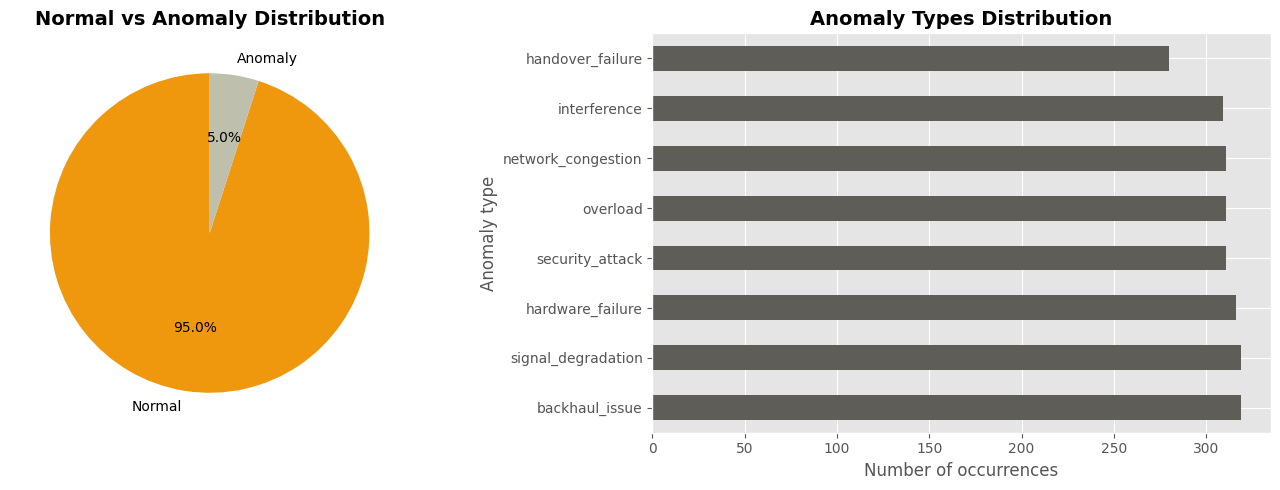

In [7]:
# Anomaly distribution
print("🚨 Anomaly distribution:")
anomaly_counts = df['anomaly'].value_counts()
print(anomaly_counts)
print(f"\n   Normal: {anomaly_counts[0]:,} ({anomaly_counts[0]/len(df)*100:.2f}%)")
print(f"   Anomalies: {anomaly_counts[1]:,} ({anomaly_counts[1]/len(df)*100:.2f}%)")

# Distribution of anomaly types
print("\n🔴 Anomaly types:")
anomaly_types = df[df['anomaly'] == 1]['anomaly_type'].value_counts()
print(anomaly_types)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Normal vs Anomaly
axes[0].pie(anomaly_counts, labels=['Normal', 'Anomaly'], autopct='%1.1f%%', 
            colors=["#ef980e", "#bfbfae"], startangle=90)
axes[0].set_title('Normal vs Anomaly Distribution', fontsize=14, fontweight='bold')

# Chart 2: Anomaly types
anomaly_types.plot(kind='barh', ax=axes[1], color="#5e5d58")
axes[1].set_title('Anomaly Types Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of occurrences')
axes[1].set_ylabel('Anomaly type')

plt.tight_layout()
plt.show()

## 5. Slice Type Distribution

📡 Slice type distribution:
slice_type
eMBB     24941
URLLC    15091
mMTC      9968
Name: count, dtype: int64
   eMBB: 24,941 (49.9%)
   URLLC: 15,091 (30.2%)
   mMTC: 9,968 (19.9%)

🔴 Anomalies by slice type:
slice_type
URLLC     767
eMBB     1217
mMTC      492
dtype: int64


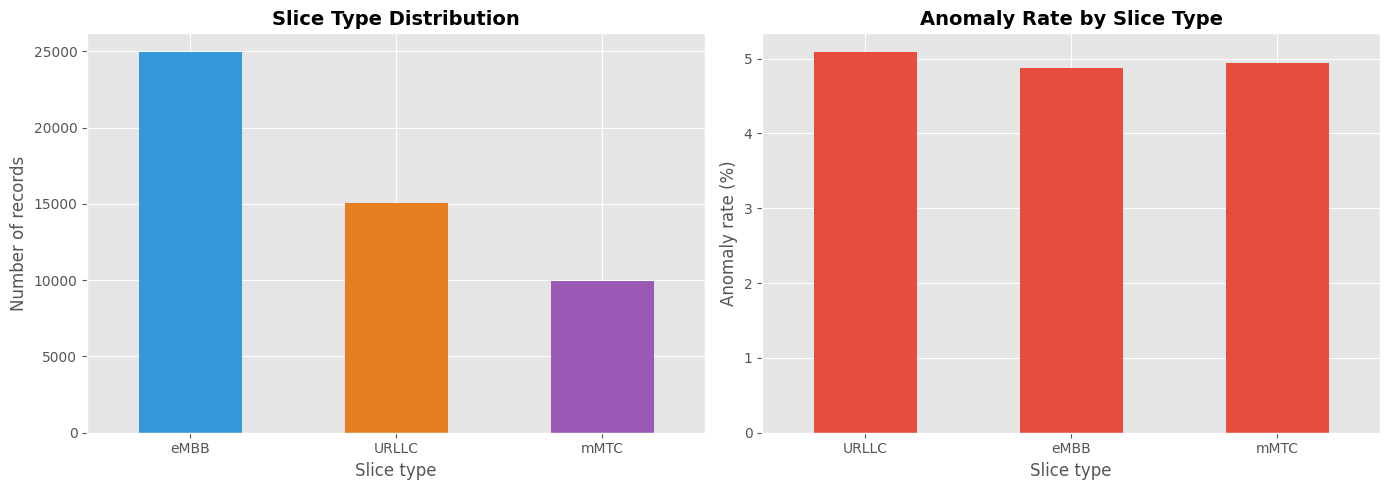

In [8]:
# Slice type distribution
print("📡 Slice type distribution:")
slice_counts = df['slice_type'].value_counts()
print(slice_counts)
for slice_type, count in slice_counts.items():
    print(f"   {slice_type}: {count:,} ({count/len(df)*100:.1f}%)")

# Anomalies by slice type
print("\n🔴 Anomalies by slice type:")
slice_anomalies = df[df['anomaly'] == 1].groupby('slice_type').size()
print(slice_anomalies)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Slice distribution
slice_counts.plot(kind='bar', ax=axes[0], color=['#3498db', '#e67e22', '#9b59b6'])
axes[0].set_title('Slice Type Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Slice type')
axes[0].set_ylabel('Number of records')
axes[0].tick_params(axis='x', rotation=0)

# Chart 2: Anomalies per slice
anomaly_rate_by_slice = df.groupby('slice_type')['anomaly'].mean() * 100
anomaly_rate_by_slice.plot(kind='bar', ax=axes[1], color='#e74c3c')
axes[1].set_title('Anomaly Rate by Slice Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Slice type')
axes[1].set_ylabel('Anomaly rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 6. KPI Descriptive Statistics

In [9]:
# Select KPI columns (numeric)
kpi_columns = [col for col in df.columns if col not in 
               ['timestamp', 'cell_id', 'ue_id', 'slice_type', 'latitude', 
                'longitude', 'anomaly', 'anomaly_type']]

print(f"📊 Descriptive statistics for {len(kpi_columns)} KPIs:")
print(f"   KPIs: {', '.join(kpi_columns[:5])}... (+ {len(kpi_columns)-5} others)")

# Descriptive statistics
df[kpi_columns].describe()

📊 Descriptive statistics for 14 KPIs:
   KPIs: one_way_latency_ms, jitter_ms, rtt_ms, packet_delay_budget_ms, handover_interruption_time_ms... (+ 9 others)


,one_way_latency_ms,jitter_ms,rtt_ms,packet_delay_budget_ms,handover_interruption_time_ms,reliability_percent,packet_loss_percent,packet_loss_rate_percent,bler_percent,throughput_dl_mbps,throughput_ul_mbps,spectral_efficiency_bps_hz,handover_success_rate_percent,energy_efficiency_bits_per_joule
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04
mean,22.441900,6.042671,46.769035,53.805606,23.713327,99.013439,1.250573,1.258028,4.595758,4866.983142,2460.527198,13.466367,99.364546,1.767692e+08
std,78.804157,8.662138,144.388693,38.810361,27.945976,2.147387,3.662746,3.734631,4.992802,5692.526298,2838.898114,7.508085,1.934475,2.429079e+08
min,0.169100,0.022700,0.608400,0.502200,0.535800,68.324500,0.000008,0.000004,0.004672,0.001800,0.003500,0.417100,59.596500,1.074400e+04
25%,3.522075,0.732575,7.556575,0.858475,7.288000,99.206700,0.000743,0.000742,0.716700,58.586575,58.721800,7.664625,99.343500,2.277928e+07
50%,9.750650,5.027250,23.672550,68.552600,23.401600,99.549200,0.454249,0.458441,4.117300,188.504450,183.884850,12.868250,99.500100,5.621842e+07
75%,16.547425,7.949225,34.569775,79.472025,33.659100,99.999300,0.811633,0.810823,6.678350,9715.062450,4894.688900,19.849500,99.655300,2.892118e+08
max,4061.598400,326.709000,7094.852500,431.082700,1063.689500,100.000000,50.805200,51.166600,80.000000,19856.559200,9896.011200,29.841200,99.996200,9.908279e+08


In [10]:
# KPI comparison: Normal vs Anomaly
# KPIs with the largest differences (%) are the most discriminant
print("📊 Average KPI comparison (Normal vs Anomaly):\n")

comparison = pd.DataFrame({
    'Normal (mean)': df[df['anomaly'] == 0][kpi_columns].mean(),
    'Anomaly (mean)': df[df['anomaly'] == 1][kpi_columns].mean(),
})
comparison['Difference (%)'] = ((comparison['Anomaly (mean)'] - comparison['Normal (mean)']) / 
                                 comparison['Normal (mean)'] * 100).round(2)

print(comparison)

# Automatic interpretation of results
print("\n" + "="*80)
print("🔍 INTERPRETATION OF RESULTS")
print("="*80)

# Sort by absolute difference
comparison_sorted = comparison.copy()
comparison_sorted['Abs_Diff'] = comparison_sorted['Difference (%)'].abs()
comparison_sorted = comparison_sorted.sort_values('Abs_Diff', ascending=False)

# Identify most discriminant KPIs
print("\n🎯 Most discriminant KPIs (|Difference| > 50%) :")
highly_discriminant = comparison_sorted[comparison_sorted['Abs_Diff'] > 50]
if len(highly_discriminant) > 0:
    for kpi in highly_discriminant.index:
        diff = comparison_sorted.loc[kpi, 'Difference (%)']
        normal_val = comparison_sorted.loc[kpi, 'Normal (mean)']
        anomaly_val = comparison_sorted.loc[kpi, 'Anomaly (mean)']
        
        if diff > 0:
            trend = "↑ INCREASES"
            impact = "DEGRADATION"
        else:
            trend = "↓ DECREASES"
            impact = "DEGRADATION" if "loss" in kpi.lower() or "error" in kpi.lower() else "IMPROVEMENT"
        
        print(f"   • {kpi}:")
        print(f"      Normal: {normal_val:.2f} → Anomaly: {anomaly_val:.2f} ({diff:+.1f}%)")
        print(f"      {trend} by {abs(diff):.1f}% → {impact}")
else:
    print("   No KPI with |Difference| > 50%")

print("\n🟡 Moderately discriminant KPIs (20% < |Difference| < 50%) :")
moderately_discriminant = comparison_sorted[(comparison_sorted['Abs_Diff'] >= 20) & 
                                             (comparison_sorted['Abs_Diff'] <= 50)]
if len(moderately_discriminant) > 0:
    for kpi in moderately_discriminant.index:
        diff = comparison_sorted.loc[kpi, 'Difference (%)']
        print(f"   • {kpi}: {diff:+.1f}%")
else:
    print("   No KPI in this category")

print("\n🟢 Low discriminant KPIs (|Difference| < 20%) :")
low_discriminant = comparison_sorted[comparison_sorted['Abs_Diff'] < 20]
if len(low_discriminant) > 0:
    print(f"   • {len(low_discriminant)} KPI(s): {', '.join(low_discriminant.index[:5].tolist())}")
    if len(low_discriminant) > 5:
        print(f"     ... and {len(low_discriminant)-5} others")
else:
    print("   No KPI in this category")

# Recommendations
print("\n💡 RECOMMENDATIONS :")
print(f"   ✓ Use the {len(highly_discriminant)} highly discriminant KPIs as main features")
print(f"   ✓ Define alert thresholds based on observed average values")
print(f"   ✓ Low discriminant KPIs can be excluded from the model for simplicity")
print(f"   ✓ Total KPIs analyzed: {len(comparison)} KPIs")

print("\n" + "="*80)

📊 Average KPI comparison (Normal vs Anomaly):

                                  Normal (mean)  Anomaly (mean)  \
one_way_latency_ms                 1.701373e+01    1.266295e+02   
jitter_ms                          5.391961e+00    1.853232e+01   
rtt_ms                             3.606948e+01    2.521347e+02   
packet_delay_budget_ms             5.259769e+01    7.699022e+01   
handover_interruption_time_ms      2.230366e+01    5.077025e+01   
reliability_percent                9.925179e+01    9.443863e+01   
packet_loss_percent                7.462686e-01    1.093012e+01   
packet_loss_rate_percent           7.449297e-01    1.110636e+01   
bler_percent                       4.157347e+00    1.301056e+01   
throughput_dl_mbps                 5.031615e+03    1.707064e+03   
throughput_ul_mbps                 2.543196e+03    8.738025e+02   
spectral_efficiency_bps_hz         1.357249e+01    1.142943e+01   
handover_success_rate_percent      9.950033e+01    9.675838e+01   
energy_efficien

## 7. Key KPI Visualization by Discrimination Level

🎯 9 highly discriminant KPIs:


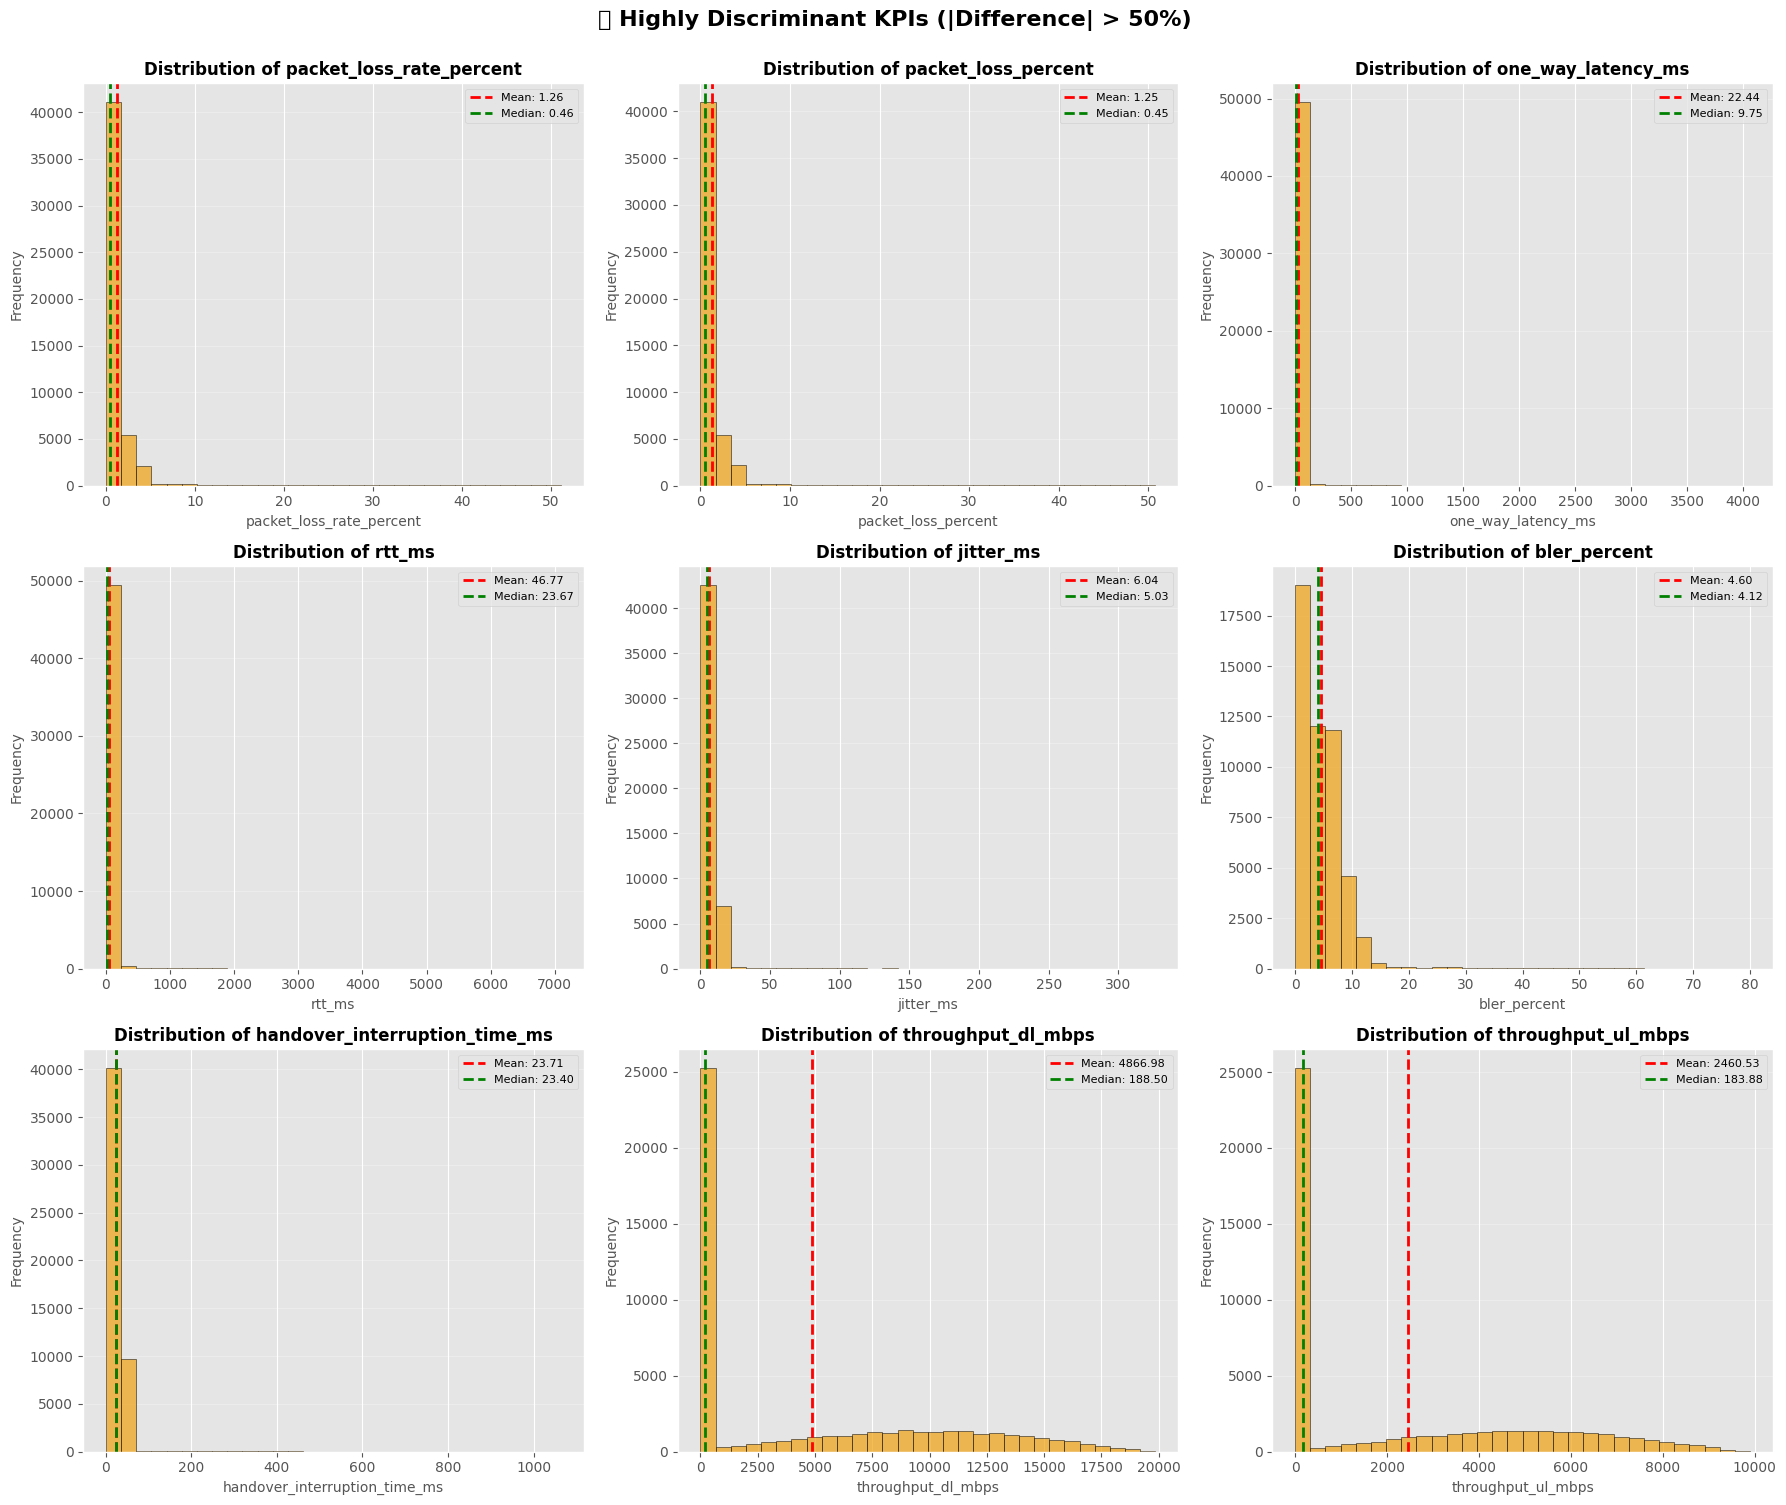


🟡 1 moderately discriminant KPIs:


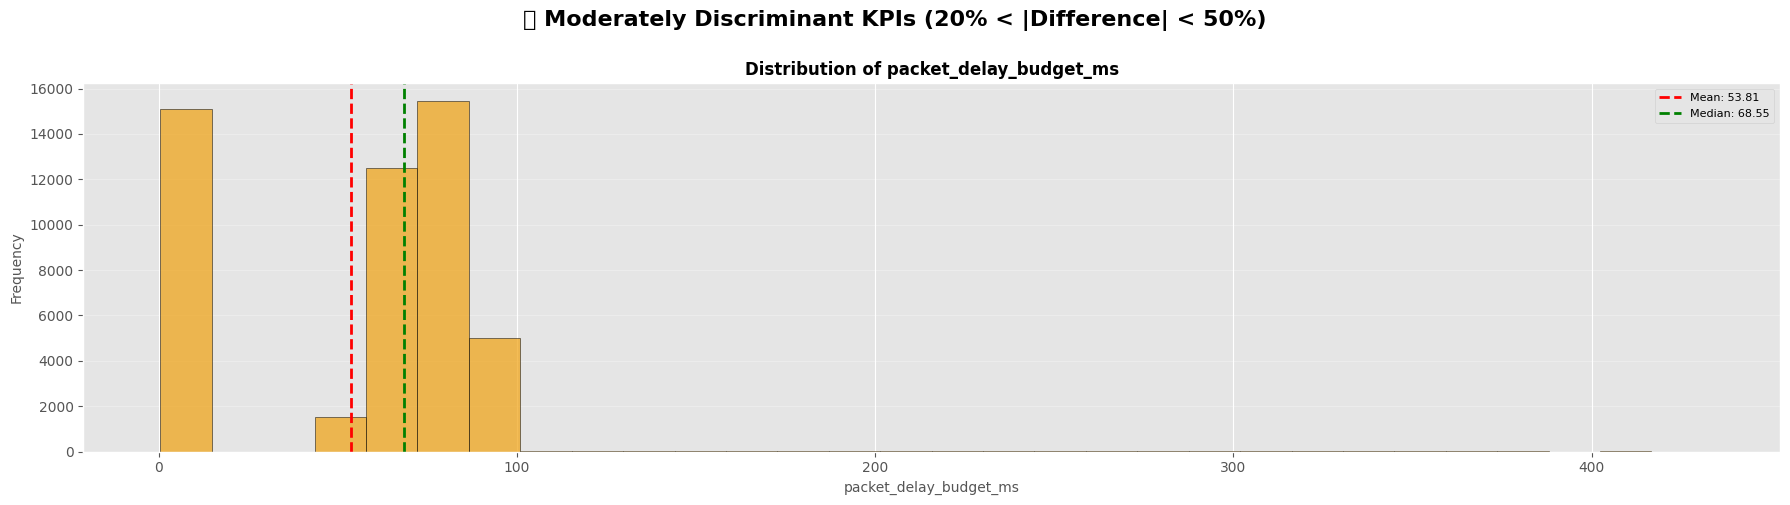


🟢 4 low discriminant KPIs:


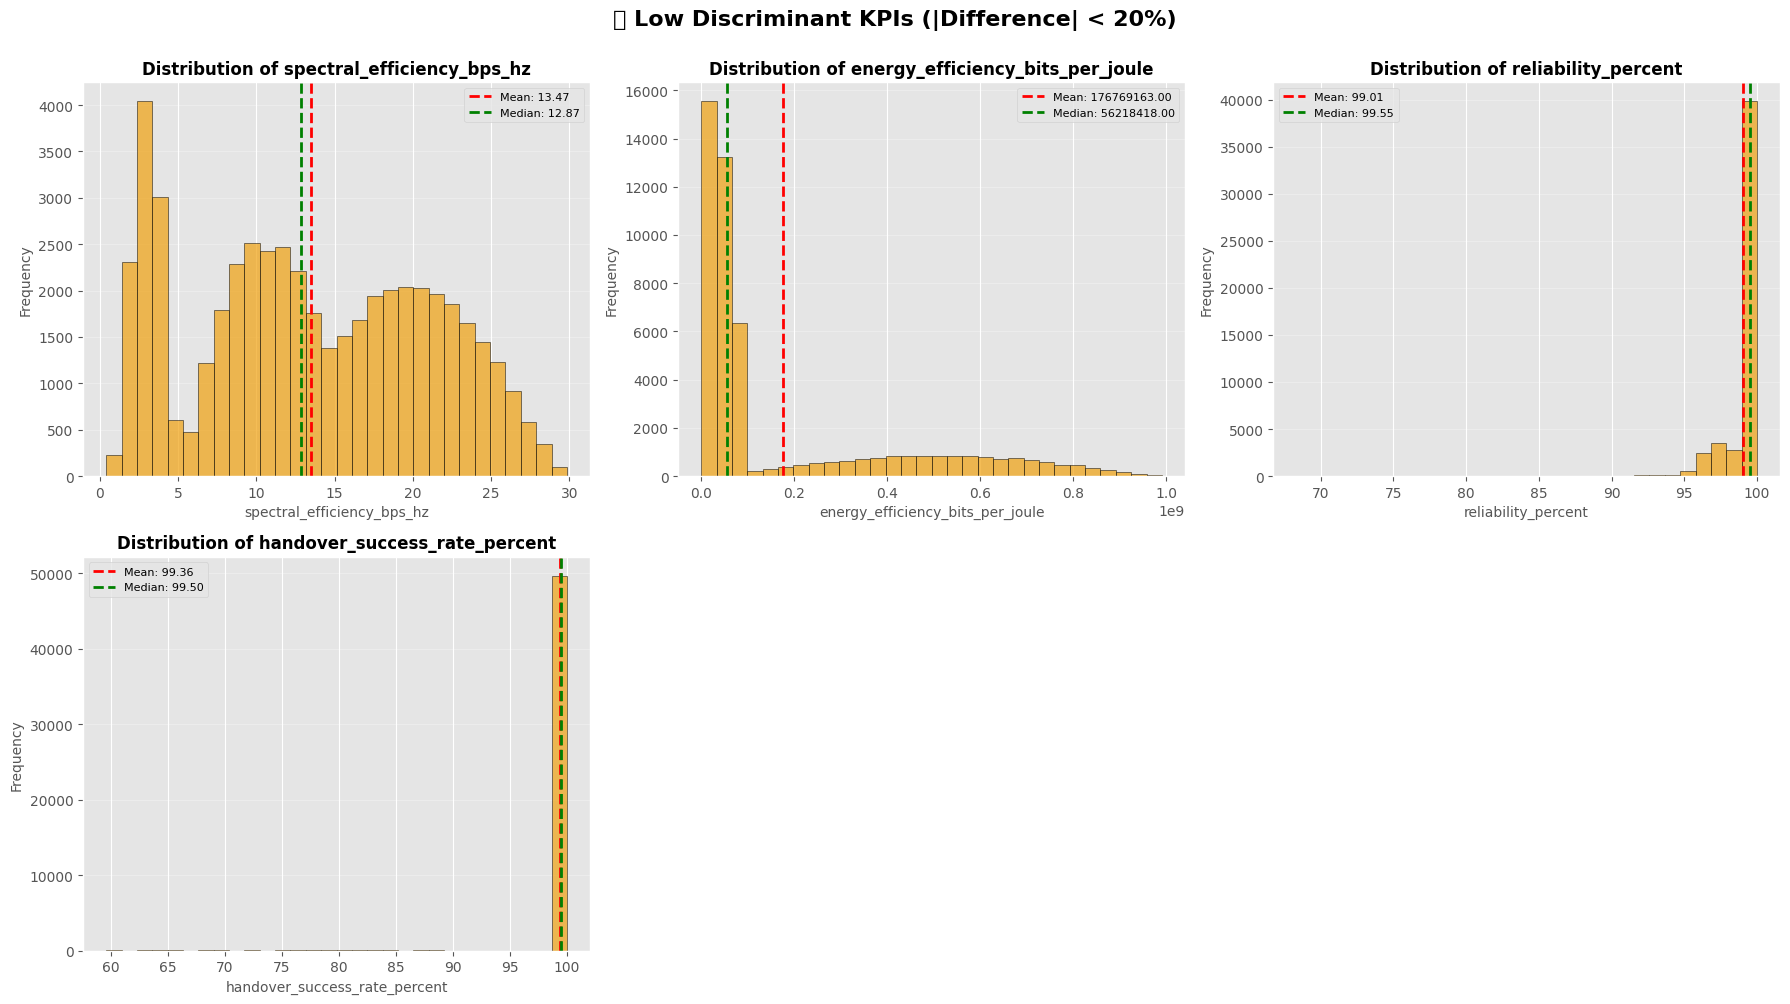

In [11]:
# =====================================================================
# Visualization of ALL KPIs grouped by discrimination level
# =====================================================================

# Calculate KPI groups
comparison_analysis = comparison.copy()
comparison_analysis['Abs_Diff'] = comparison_analysis['Difference (%)'].abs()

highly_discriminant_kpis = comparison_analysis[comparison_analysis['Abs_Diff'] > 50].sort_values('Abs_Diff', ascending=False).index.tolist()
moderately_discriminant_kpis = comparison_analysis[(comparison_analysis['Abs_Diff'] >= 20) & (comparison_analysis['Abs_Diff'] <= 50)].sort_values('Abs_Diff', ascending=False).index.tolist()
low_discriminant_kpis = comparison_analysis[comparison_analysis['Abs_Diff'] < 20].sort_values('Abs_Diff', ascending=False).index.tolist()

# Function to create histograms for a group
def plot_kpi_group(kpis, title):
    if len(kpis) == 0:
        print(f"⚠️ No KPI in group: {title}")
        return
    n_kpis = len(kpis)
    n_cols = min(3, n_kpis)
    n_rows = int(np.ceil(n_kpis / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
    if n_kpis == 1:
        axes = np.array([axes])
    axes = np.array(axes).ravel()
    for idx, kpi in enumerate(kpis):
        axes[idx].hist(df[kpi], bins=30, color="#f0a10f",
                       alpha=0.7, edgecolor='black')
        axes[idx].set_title(f'Distribution of {kpi}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(kpi, fontsize=10)
        axes[idx].set_ylabel('Frequency', fontsize=10)
        axes[idx].grid(axis='y', alpha=0.3)

        # Statistics: mean and median
        mean_val = df[kpi].mean()
        median_val = df[kpi].median()
        axes[idx].axvline(mean_val, color='red', linestyle='--',
                          linewidth=2, label=f'Mean: {mean_val:.2f}')
        axes[idx].axvline(median_val, color='green', linestyle='--',
                          linewidth=2, label=f'Median: {median_val:.2f}')
        axes[idx].legend(fontsize=8)
    for idx in range(n_kpis, len(axes)):
        axes[idx].set_visible(False)
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

# --- Block 1: Highly discriminant KPIs (|Diff| > 50%) ---
print(f"🎯 {len(highly_discriminant_kpis)} highly discriminant KPIs:")
plot_kpi_group(highly_discriminant_kpis, 
               '🎯 Highly Discriminant KPIs (|Difference| > 50%)')

# --- Block 2: Moderately discriminant KPIs (20-50%) ---
print(f"\n🟡 {len(moderately_discriminant_kpis)} moderately discriminant KPIs:")
plot_kpi_group(moderately_discriminant_kpis, 
               '🟡 Moderately Discriminant KPIs (20% < |Difference| < 50%)')

# --- Block 3: Low discriminant KPIs (<20%) ---
print(f"\n🟢 {len(low_discriminant_kpis)} low discriminant KPIs:")
plot_kpi_group(low_discriminant_kpis, 
               '🟢 Low Discriminant KPIs (|Difference| < 20%)')

🎯 9 highly discriminant KPIs (Box Plots):


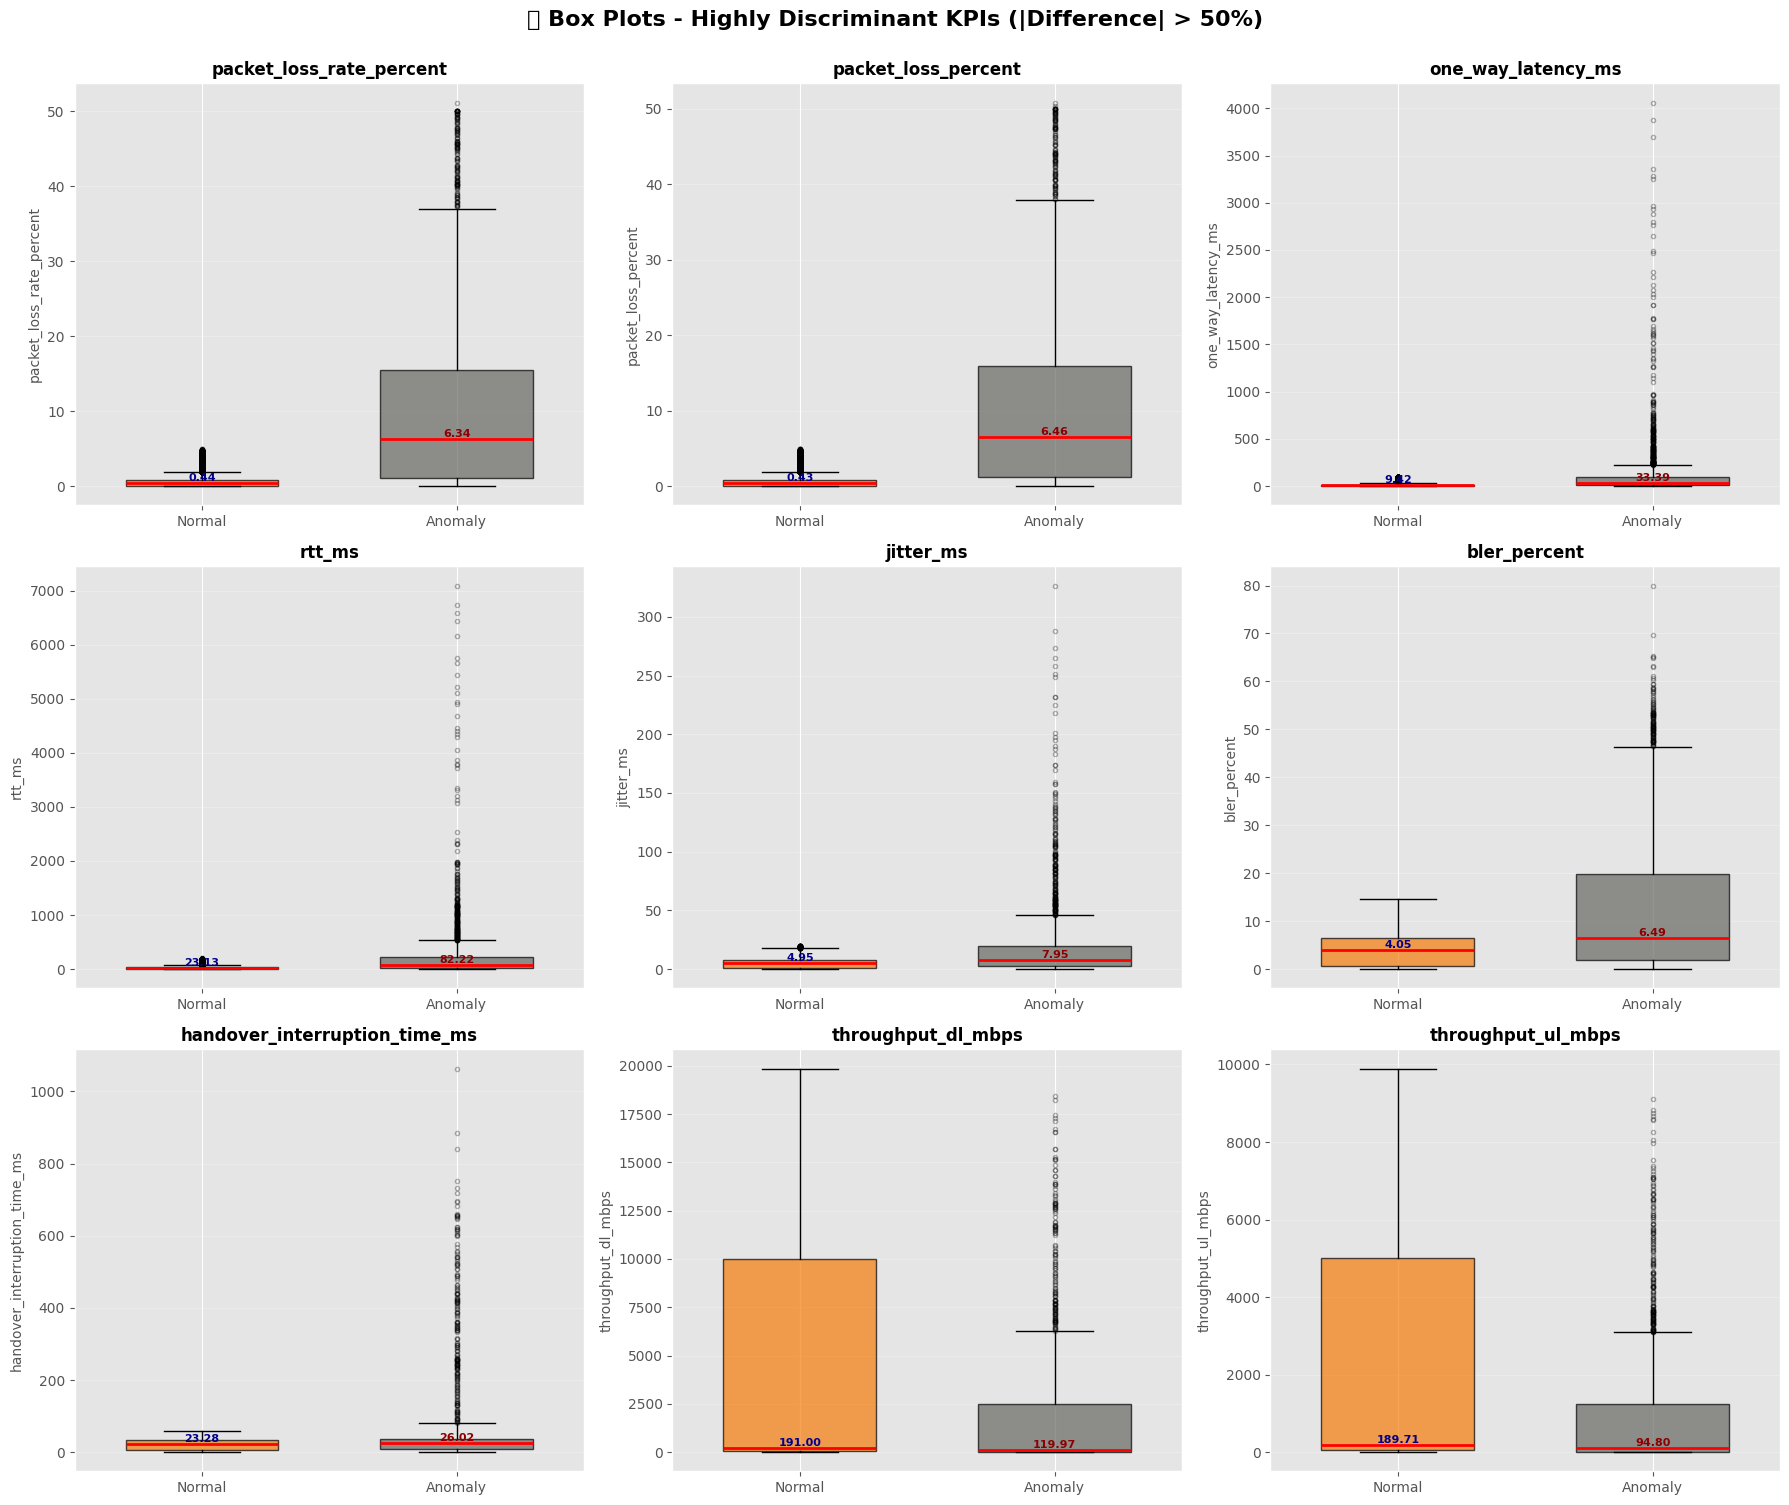


🟡 1 moderately discriminant KPIs (Box Plots):


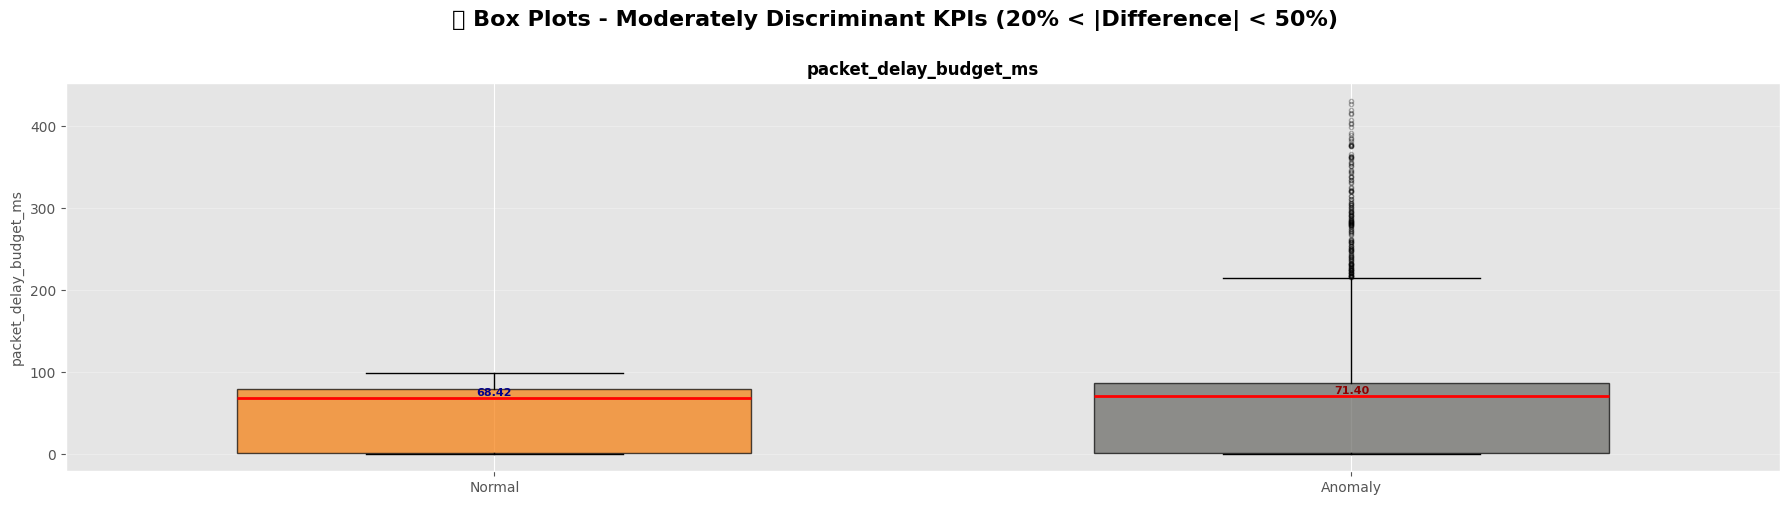


🟢 4 low discriminant KPIs (Box Plots):


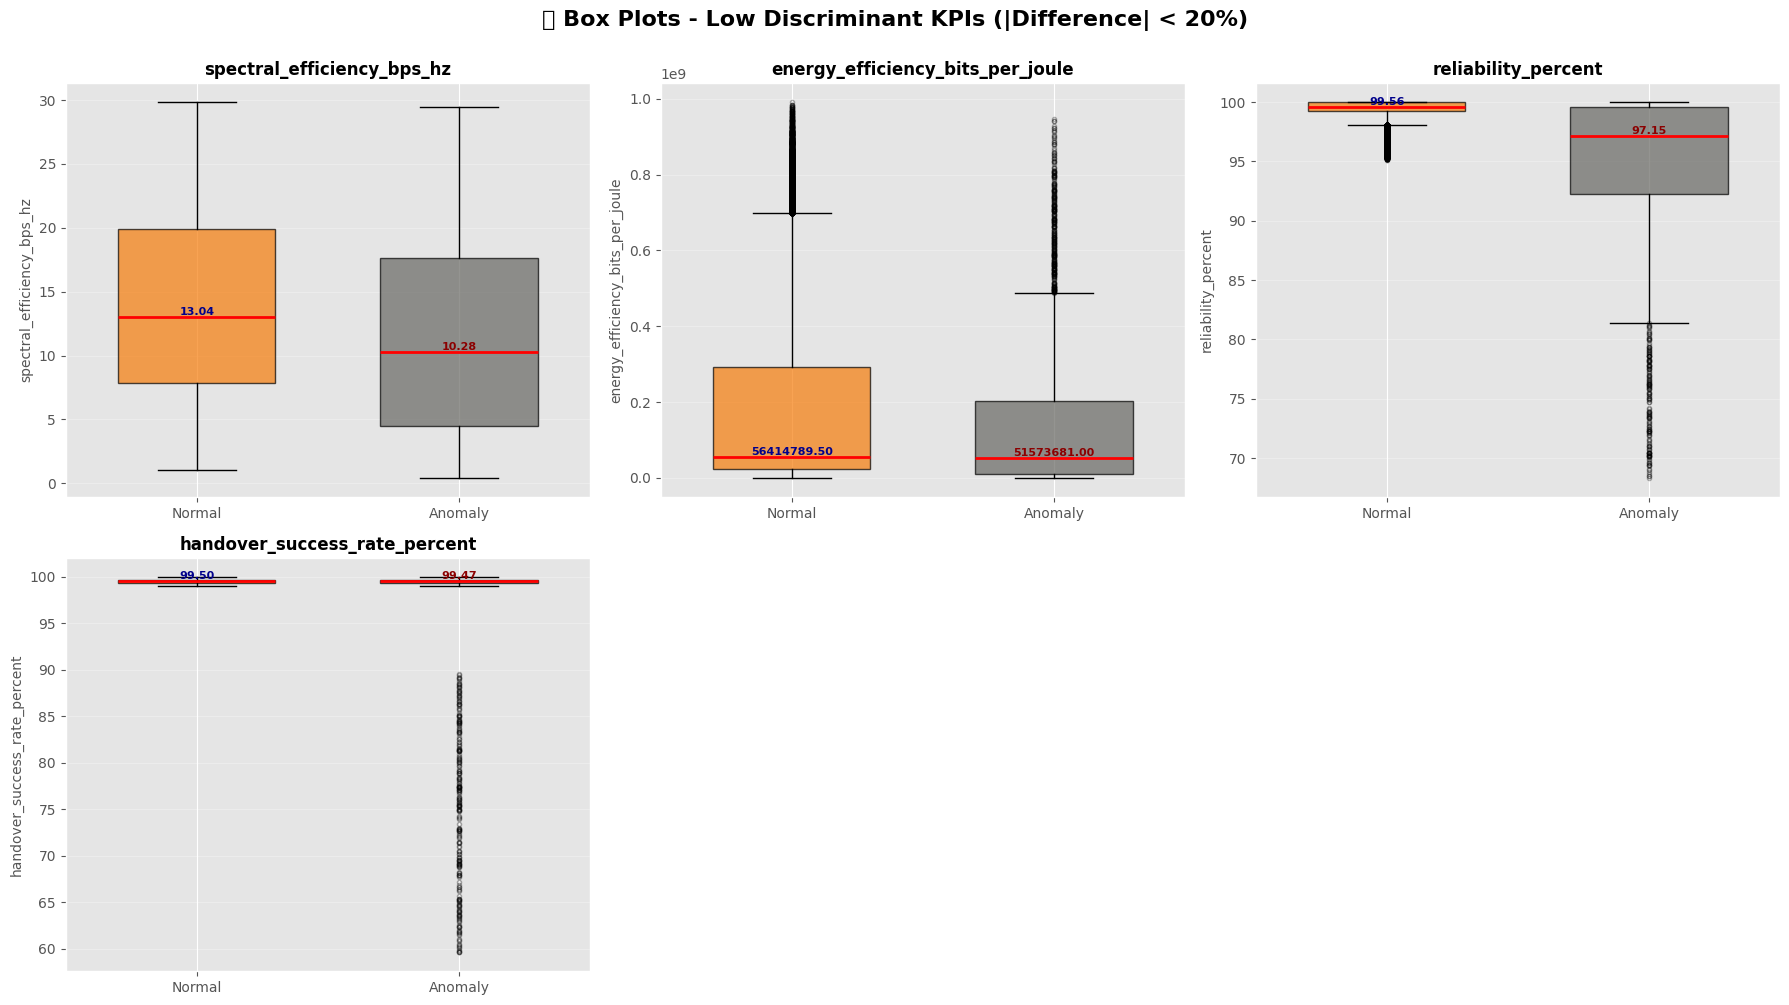

In [12]:
# =====================================================================
# Box Plots of ALL KPIs grouped by discrimination level
# Normal vs Anomaly
# =====================================================================

def plot_kpi_boxplots(kpis, title):
    if len(kpis) == 0:
        print(f"⚠️ No KPI in group: {title}")
        return
    n_kpis = len(kpis)
    n_cols = min(3, n_kpis)
    n_rows = int(np.ceil(n_kpis / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
    if n_kpis == 1:
        axes = np.array([axes])
    axes = np.array(axes).ravel()
    
    for idx, kpi in enumerate(kpis):
        data_normal = df[df['anomaly'] == 0][kpi]
        data_anomaly = df[df['anomaly'] == 1][kpi]
        
        bp = axes[idx].boxplot([data_normal, data_anomaly],
                               labels=['Normal', 'Anomaly'],
                               patch_artist=True,
                               widths=0.6,
                               medianprops=dict(color='red', linewidth=2),
                               flierprops=dict(marker='o', markersize=3, alpha=0.3))
        
        # Box colors
        bp['boxes'][0].set_facecolor("#f67c0a")
        bp['boxes'][0].set_alpha(0.7)
        bp['boxes'][1].set_facecolor("#676762")
        bp['boxes'][1].set_alpha(0.7)
        
        axes[idx].set_title(f'{kpi}', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel(kpi, fontsize=10)
        axes[idx].grid(axis='y', alpha=0.3)
        
        # Annotate medians
        med_n = data_normal.median()
        med_a = data_anomaly.median()
        axes[idx].annotate(f'{med_n:.2f}', xy=(1, med_n), fontsize=8, 
                          color='darkblue', fontweight='bold', ha='center', va='bottom')
        axes[idx].annotate(f'{med_a:.2f}', xy=(2, med_a), fontsize=8, 
                          color='darkred', fontweight='bold', ha='center', va='bottom')
    
    for idx in range(n_kpis, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

# --- Block 1: Highly discriminant KPIs ---
print(f"🎯 {len(highly_discriminant_kpis)} highly discriminant KPIs (Box Plots):")
plot_kpi_boxplots(highly_discriminant_kpis, 
                  '🎯 Box Plots - Highly Discriminant KPIs (|Difference| > 50%)')

# --- Block 2: Moderately discriminant KPIs ---
print(f"\n🟡 {len(moderately_discriminant_kpis)} moderately discriminant KPIs (Box Plots):")
plot_kpi_boxplots(moderately_discriminant_kpis, 
                  '🟡 Box Plots - Moderately Discriminant KPIs (20% < |Difference| < 50%)')

# --- Block 3: Low discriminant KPIs ---
print(f"\n🟢 {len(low_discriminant_kpis)} low discriminant KPIs (Box Plots):")
plot_kpi_boxplots(low_discriminant_kpis, 
                  '🟢 Box Plots - Low Discriminant KPIs (|Difference| < 20%)')

## 7.bis Statistical Tests 

Statistical tests to answer key business questions about the 5G network.

In [13]:
from scipy import stats

print("="*90)
print("📊 STATISTICAL TESTS - BUSINESS UNDERSTANDING")
print("="*90)

# =====================================================================
# Q1: Do anomalies significantly degrade network KPIs?
# Mann-Whitney U test (non-parametric) for each KPI
# =====================================================================
print("\n" + "─"*90)
print("❓ Q1: Do anomalies significantly degrade network KPIs?")
print("   Test: Mann-Whitney U (Normal vs Anomaly comparison for each KPI)")
print("─"*90)

mann_whitney_results = []
for kpi in kpi_columns:
    normal_vals = df[df['anomaly'] == 0][kpi].dropna()
    anomaly_vals = df[df['anomaly'] == 1][kpi].dropna()
    stat, p_value = stats.mannwhitneyu(normal_vals, anomaly_vals, alternative='two-sided')
    mann_whitney_results.append({
        'KPI': kpi,
        'U-Statistic': round(stat, 2),
        'P-Value': p_value,
        'Significant (p<0.05)': '✅ YES' if p_value < 0.05 else '❌ NO',
        'Interpretation': 'Significant difference' if p_value < 0.05 else 'No difference'
    })

mw_df = pd.DataFrame(mann_whitney_results)
print(mw_df.to_string(index=False))

sig_count = sum(1 for r in mann_whitney_results if r['P-Value'] < 0.05)
print(f"\n💡 Conclusion: {sig_count}/{len(kpi_columns)} KPIs are significantly different between Normal and Anomaly")
print(f"   → Anomalies have a statistically proven impact on {sig_count} network indicators")

# =====================================================================
# Q2: Are certain slice types more vulnerable to anomalies?
# Chi-squared independence test (slice_type vs anomaly)
# =====================================================================
print("\n" + "─"*90)
print("❓ Q2: Are certain slice types more vulnerable to anomalies?")
print("   Test: Chi-squared independence test (slice_type × anomaly)")
print("─"*90)

contingency_table = pd.crosstab(df['slice_type'], df['anomaly'], margins=True)
print("\nContingency table:")
print(contingency_table)

chi2, p_chi2, dof, expected = stats.chi2_contingency(
    pd.crosstab(df['slice_type'], df['anomaly'])
)
print(f"\n   Chi² = {chi2:.4f}")
print(f"   Degrees of freedom = {dof}")
print(f"   P-value = {p_chi2:.6f}")
print(f"   Result: {'✅ Significant dependence' if p_chi2 < 0.05 else '❌ Independence'}")

if p_chi2 < 0.05:
    print(f"\n💡 Conclusion: Slice type SIGNIFICANTLY influences the anomaly rate")
    anomaly_rates = df.groupby('slice_type')['anomaly'].mean() * 100
    most_vulnerable = anomaly_rates.idxmax()
    print(f"   → Most vulnerable slice: {most_vulnerable} ({anomaly_rates[most_vulnerable]:.2f}%)")
    least_vulnerable = anomaly_rates.idxmin()
    print(f"   → Least vulnerable slice: {least_vulnerable} ({anomaly_rates[least_vulnerable]:.2f}%)")
else:
    print(f"\n💡 Conclusion: No significant link between slice type and anomalies")

# =====================================================================
# Q3: Is there a relationship between anomaly type and slice type?
# Chi-squared test (anomaly_type vs slice_type)
# =====================================================================
print("\n" + "─"*90)
print("❓ Q3: Are certain anomaly types specific to certain slices?")
print("   Test: Chi-squared independence test (anomaly_type × slice_type)")
print("─"*90)

df_anomalies = df[df['anomaly'] == 1]
contingency_anomaly_slice = pd.crosstab(df_anomalies['anomaly_type'], df_anomalies['slice_type'])
print("\nContingency table (anomaly_type × slice_type):")
print(contingency_anomaly_slice)

chi2_as, p_as, dof_as, expected_as = stats.chi2_contingency(contingency_anomaly_slice)
print(f"\n   Chi² = {chi2_as:.4f}")
print(f"   P-value = {p_as:.6f}")
print(f"   Result: {'✅ Significant dependence' if p_as < 0.05 else '❌ Independence'}")

if p_as < 0.05:
    print(f"\n💡 Conclusion: Certain anomaly types are more frequent in certain slices")
else:
    print(f"\n💡 Conclusion: Anomalies are evenly distributed across slices")

# =====================================================================
# Q4: Do network KPIs follow a normal distribution?
# Shapiro-Wilk test (on a sample)
# =====================================================================
print("\n" + "─"*90)
print("❓ Q4: Do KPIs follow a normal distribution?")
print("   Test: Shapiro-Wilk (sample of 5000 observations)")
print("   → Important for choosing the right ML models")
print("─"*90)

shapiro_results = []
sample_size = min(5000, len(df))
for kpi in kpi_columns:
    sample = df[kpi].dropna().sample(n=sample_size, random_state=42)
    stat_sw, p_sw = stats.shapiro(sample)
    shapiro_results.append({
        'KPI': kpi,
        'W-Statistic': round(stat_sw, 4),
        'P-Value': p_sw,
        'Normal distribution': '✅ YES' if p_sw > 0.05 else '❌ NO'
    })

sw_df = pd.DataFrame(shapiro_results)
print(sw_df.to_string(index=False))

normal_count = sum(1 for r in shapiro_results if r['P-Value'] > 0.05)
print(f"\n💡 Conclusion: {normal_count}/{len(kpi_columns)} KPIs follow a normal distribution")
if normal_count < len(kpi_columns) // 2:
    print(f"   → Prefer non-parametric models (Random Forest, KNN, etc.)")
else:
    print(f"   → Parametric models (Logistic Regression, etc.) are suitable")

# =====================================================================
# Q5: Do KPIs vary significantly by anomaly type?
# Kruskal-Wallis test (comparison across all anomaly types)
# =====================================================================
print("\n" + "─"*90)
print("❓ Q5: Do different anomaly types have distinct KPI signatures?")
print("   Test: Kruskal-Wallis (KPI comparison across anomaly types)")
print("─"*90)

kruskal_results = []
anomaly_types_list = df_anomalies['anomaly_type'].unique()

for kpi in kpi_columns:
    groups = [df_anomalies[df_anomalies['anomaly_type'] == at][kpi].dropna() 
              for at in anomaly_types_list]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
        stat_kw, p_kw = stats.kruskal(*groups)
        kruskal_results.append({
            'KPI': kpi,
            'H-Statistic': round(stat_kw, 2),
            'P-Value': p_kw,
            'Significant': '✅ YES' if p_kw < 0.05 else '❌ NO'
        })

kw_df = pd.DataFrame(kruskal_results)
print(kw_df.to_string(index=False))

sig_kw = sum(1 for r in kruskal_results if r['P-Value'] < 0.05)
print(f"\n💡 Conclusion: {sig_kw}/{len(kruskal_results)} KPIs vary significantly by anomaly type")
if sig_kw > len(kruskal_results) // 2:
    print(f"   → Anomaly types have DISTINCT network signatures")
    print(f"   → A multi-class model can identify the TYPE of anomaly (not just its presence)")
else:
    print(f"   → Anomaly types are hard to distinguish by KPIs")


# =====================================================================
# GLOBAL SUMMARY
# =====================================================================
print("\n" + "="*90)
print("📋 GLOBAL SUMMARY OF STATISTICAL TESTS")
print("="*90)
print(f"\n   Q1 - Impact of anomalies on KPIs:         {sig_count}/{len(kpi_columns)} KPIs significantly impacted")
print(f"   Q2 - Vulnerability by slice:               {'YES - significant differences' if p_chi2 < 0.05 else 'NO - no difference'}")
print(f"   Q3 - Anomalies specific to slices:         {'YES - significant dependence' if p_as < 0.05 else 'NO - uniform distribution'}")
print(f"   Q4 - KPI normality:                        {normal_count}/{len(kpi_columns)} normal KPIs")
print(f"   Q5 - Distinct signatures by anomaly type:  {sig_kw}/{len(kruskal_results)} discriminant KPIs")

📊 STATISTICAL TESTS - BUSINESS UNDERSTANDING

──────────────────────────────────────────────────────────────────────────────────────────
❓ Q1: Do anomalies significantly degrade network KPIs?
   Test: Mann-Whitney U (Normal vs Anomaly comparison for each KPI)
──────────────────────────────────────────────────────────────────────────────────────────
                             KPI  U-Statistic       P-Value Significant (p<0.05)         Interpretation
              one_way_latency_ms   29223427.0  0.000000e+00                ✅ YES Significant difference
                       jitter_ms   39351045.0 2.143098e-170                ✅ YES Significant difference
                          rtt_ms   29143132.5  0.000000e+00                ✅ YES Significant difference
          packet_delay_budget_ms   50482211.5  8.407161e-33                ✅ YES Significant difference
   handover_interruption_time_ms   52629711.5  7.888704e-19                ✅ YES Significant difference
             reliability_

## 8. Correlation Matrix

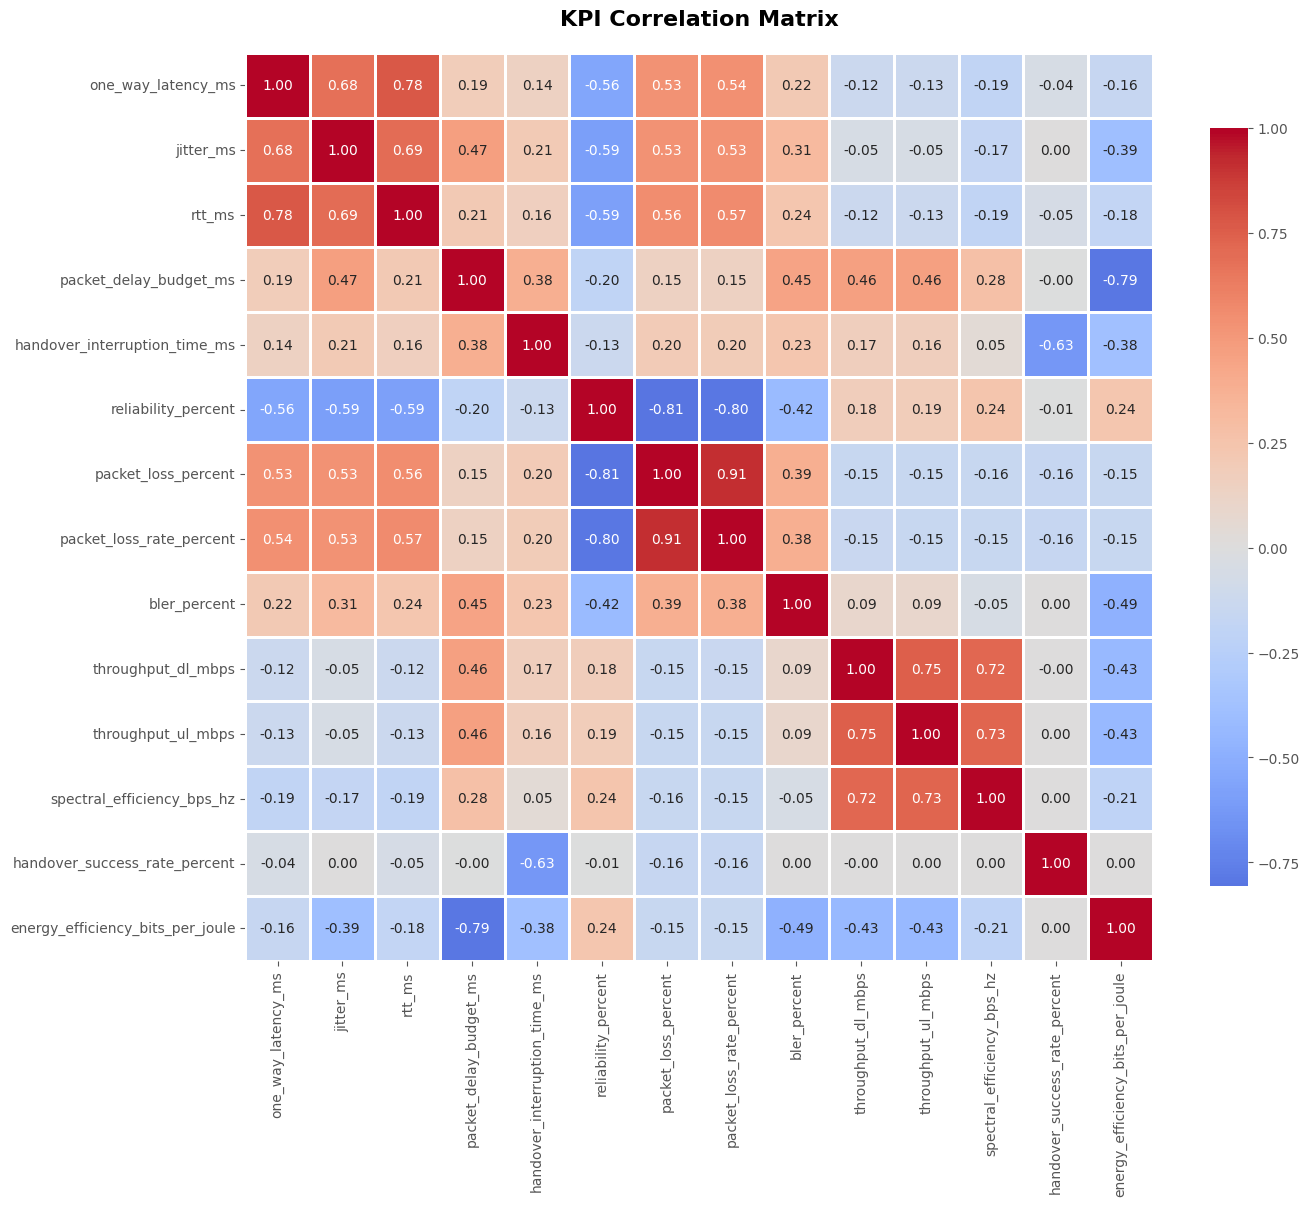


🔗 Strong correlations (|r| > 0.7):
                 KPI 1                            KPI 2  Correlation
    one_way_latency_ms                           rtt_ms        0.779
packet_delay_budget_ms energy_efficiency_bits_per_joule       -0.792
   reliability_percent              packet_loss_percent       -0.806
   reliability_percent         packet_loss_rate_percent       -0.797
   packet_loss_percent         packet_loss_rate_percent        0.911
    throughput_dl_mbps               throughput_ul_mbps        0.751
    throughput_dl_mbps       spectral_efficiency_bps_hz        0.724
    throughput_ul_mbps       spectral_efficiency_bps_hz        0.725


In [14]:
# KPI correlation matrix
correlation_matrix = df[kpi_columns].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('KPI Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identify strongest correlations (>0.7 or <-0.7)
print("\n🔗 Strong correlations (|r| > 0.7):")
strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            strong_corr.append({
                'KPI 1': correlation_matrix.columns[i],
                'KPI 2': correlation_matrix.columns[j],
                'Correlation': round(correlation_matrix.iloc[i, j], 3)
            })

if strong_corr:
    strong_corr_df = pd.DataFrame(strong_corr)
    print(strong_corr_df.to_string(index=False))
else:
    print("No strong correlation detected.")

## 9. Temporal Analysis

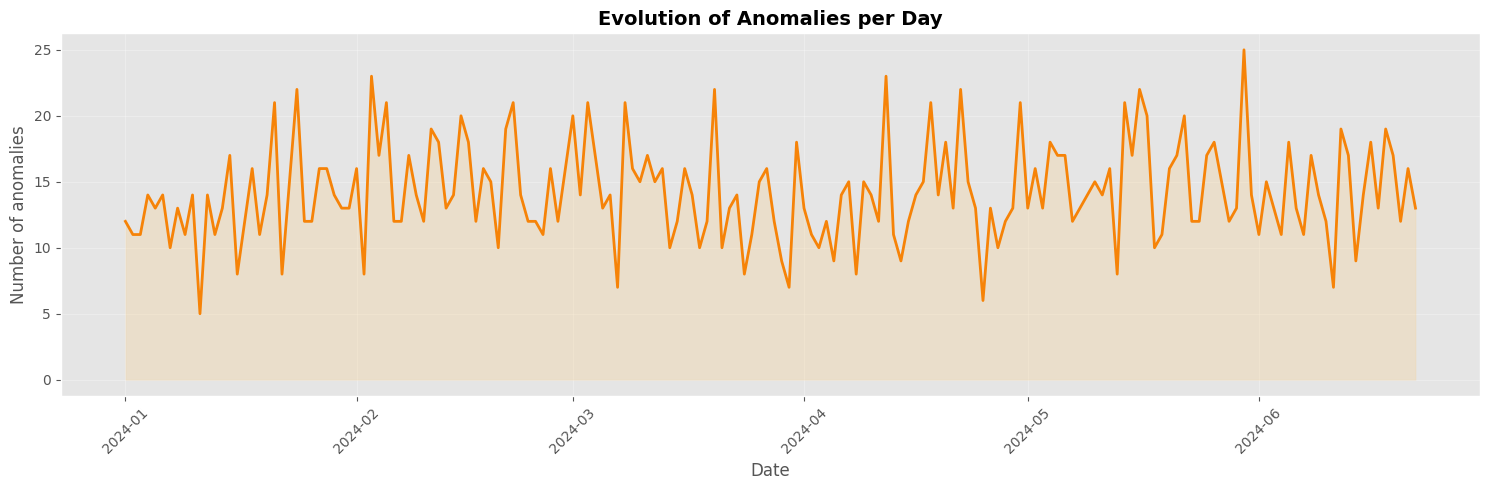

📅 Temporal statistics:
   Period covered: 2024-01-01 to 2024-06-22
   Number of days: 174
   Average anomaly rate per day: 4.96%


In [15]:
# Temporal evolution of anomalies
df['date'] = df['timestamp'].dt.date

# Anomalies per day
daily_anomalies = df.groupby('date')['anomaly'].agg(['sum', 'count'])
daily_anomalies['rate'] = (daily_anomalies['sum'] / daily_anomalies['count'] * 100)

# Visualization
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(daily_anomalies.index, daily_anomalies['sum'], color="#f68308", linewidth=2)
ax.fill_between(daily_anomalies.index, daily_anomalies['sum'], alpha=0.3, color="#F6CF8F")
ax.set_title('Evolution of Anomalies per Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Number of anomalies')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("📅 Temporal statistics:")
print(f"   Period covered: {df['date'].min()} to {df['date'].max()}")
print(f"   Number of days: {df['date'].nunique()}")
print(f"   Average anomaly rate per day: {daily_anomalies['rate'].mean():.2f}%")

# =====================================================================
# PREPROCESSING
# =====================================================================

## Step 1: Handling Identifier and Temporal Columns

In [16]:
# =====================================================================
# 1.1 Extract temporal components from timestamp
# =====================================================================

df['year']   = df['timestamp'].dt.year
df['month']  = df['timestamp'].dt.month
df['day']    = df['timestamp'].dt.day
df['hour']   = df['timestamp'].dt.hour
df['minute'] = df['timestamp'].dt.minute
df['second'] = df['timestamp'].dt.second

print("Temporal columns extracted:")
print(df[['timestamp', 'year', 'month', 'day', 'hour', 'minute', 'second']].head(10))

Temporal columns extracted:
            timestamp  year  month  day  hour  minute  second
0 2024-01-01 00:04:46  2024      1    1     0       4      46
1 2024-01-01 00:10:25  2024      1    1     0      10      25
2 2024-01-01 00:15:06  2024      1    1     0      15       6
3 2024-01-01 00:20:12  2024      1    1     0      20      12
4 2024-01-01 00:25:14  2024      1    1     0      25      14
5 2024-01-01 00:30:16  2024      1    1     0      30      16
6 2024-01-01 00:35:13  2024      1    1     0      35      13
7 2024-01-01 00:40:22  2024      1    1     0      40      22
8 2024-01-01 00:44:33  2024      1    1     0      44      33
9 2024-01-01 00:50:02  2024      1    1     0      50       2


In [17]:
# =====================================================================
# 1.2 Drop non-predictive identifier columns
# =====================================================================
# timestamp is kept in the DataFrame for reference but will be excluded from features (X) during modeling

columns_to_drop = ['cell_id', 'ue_id', 'date']
df.drop(columns=columns_to_drop, inplace=True)

print(f"Dropped columns: {columns_to_drop}")
print(f"Note: 'timestamp' is kept in the DataFrame but will be excluded from features during modeling.")
print(f"\nNew dataset dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nRemaining columns:\n{list(df.columns)}")

Dropped columns: ['cell_id', 'ue_id', 'date']
Note: 'timestamp' is kept in the DataFrame but will be excluded from features during modeling.

New dataset dimensions: 50,000 rows x 26 columns

Remaining columns:
['timestamp', 'slice_type', 'latitude', 'longitude', 'one_way_latency_ms', 'jitter_ms', 'rtt_ms', 'packet_delay_budget_ms', 'handover_interruption_time_ms', 'reliability_percent', 'packet_loss_percent', 'packet_loss_rate_percent', 'bler_percent', 'throughput_dl_mbps', 'throughput_ul_mbps', 'spectral_efficiency_bps_hz', 'handover_success_rate_percent', 'energy_efficiency_bits_per_joule', 'anomaly', 'anomaly_type', 'year', 'month', 'day', 'hour', 'minute', 'second']


In [18]:
# =====================================================================
# 1.3 Encode slice_type (Label Encoding)
# =====================================================================
# Only 3 categories (eMBB, URLLC, mMTC) -> Label Encoding is sufficient

le_slice = LabelEncoder()
df['slice_type'] = le_slice.fit_transform(df['slice_type'])

print("slice_type encoding (Label Encoding):")
for label, encoded in zip(le_slice.classes_, le_slice.transform(le_slice.classes_)):
    print(f"   {label} -> {encoded}")

print(f"\nDistribution after encoding:")
print(df['slice_type'].value_counts().sort_index())

slice_type encoding (Label Encoding):
   URLLC -> 0
   eMBB -> 1
   mMTC -> 2

Distribution after encoding:
slice_type
0    15091
1    24941
2     9968
Name: count, dtype: int64


In [19]:
# =====================================================================
# 1.4 DataFrame state verification after Step 1
# =====================================================================

print("="*70)
print("VERIFICATION - DATAFRAME STATE AFTER STEP 1")
print("="*70)
print(f"\nDimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumn types:")
print(df.dtypes)
print(f"\nPreview:")
df.head()

VERIFICATION - DATAFRAME STATE AFTER STEP 1

Dimensions: 50,000 rows x 26 columns

Column types:
timestamp                           datetime64[ns]
slice_type                                   int64
latitude                                   float64
longitude                                  float64
one_way_latency_ms                         float64
jitter_ms                                  float64
rtt_ms                                     float64
packet_delay_budget_ms                     float64
handover_interruption_time_ms              float64
reliability_percent                        float64
packet_loss_percent                        float64
packet_loss_rate_percent                   float64
bler_percent                               float64
throughput_dl_mbps                         float64
throughput_ul_mbps                         float64
spectral_efficiency_bps_hz                 float64
handover_success_rate_percent              float64
energy_efficiency_bits_per_joule    

,timestamp,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,rtt_ms,packet_delay_budget_ms,handover_interruption_time_ms,reliability_percent,packet_loss_percent,packet_loss_rate_percent,bler_percent,throughput_dl_mbps,throughput_ul_mbps,spectral_efficiency_bps_hz,handover_success_rate_percent,energy_efficiency_bits_per_joule,anomaly,anomaly_type,year,month,day,hour,minute,second
0,2024-01-01 00:04:46,1,33.852372,-7.432579,6.5374,5.6247,21.9347,72.3138,24.1853,99.6704,0.282045,0.566823,4.045900,8838.0518,5886.2035,17.4116,99.4285,51054585.0,0,normal,2024,1,1,0,4,46
1,2024-01-01 00:10:25,0,34.091446,-7.549245,2.9853,0.7240,1.9772,0.6080,4.4692,99.9996,0.000878,0.000413,0.206868,41.8399,88.1483,13.1571,99.1853,427078719.0,0,normal,2024,1,1,0,10,25
2,2024-01-01 00:15:06,1,33.977857,-7.571867,10.2100,7.0577,30.3852,61.2198,31.1128,99.5963,0.431412,0.300520,7.398000,4906.4537,3563.4036,21.7581,99.6506,75943423.0,0,normal,2024,1,1,0,15,6
3,2024-01-01 00:20:12,0,33.632320,-7.612415,3.6215,0.5090,5.2518,0.7182,7.4262,99.9992,0.000213,0.000767,0.598360,161.2519,137.6901,9.0040,99.7065,632802493.0,0,normal,2024,1,1,0,20,12
4,2024-01-01 00:25:14,1,33.663517,-7.624125,18.1355,4.1159,39.6563,57.4942,10.2636,99.3952,0.562552,0.232454,2.927900,10993.1108,4959.7092,19.8583,99.6954,40902946.0,0,normal,2024,1,1,0,25,14


In [20]:
# =====================================================================
# Create a clean copy of the DataFrame for preprocessing
# =====================================================================
# df is preserved as the original (post-Step 1), df_clean is used from now on

df_clean = df.copy()

print(f"df_clean created: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
print(f"Original df is preserved separately.")

df_clean created: 50,000 rows x 26 columns
Original df is preserved separately.


## 2. Feautres and Target Separation:

In [21]:
# =====================================================================
# 2.1 Define Features (X) and Targets (y1, y2)
# =====================================================================

# Columns to exclude from features
exclude_cols = ['timestamp', 'anomaly', 'anomaly_type']

# Features: 14 KPIs + slice_type (encoded) + latitude + longitude + 6 temporal components
X = df_clean.drop(columns=exclude_cols)

# Target 1: Binary classification (0 = Normal, 1 = Anomaly)
y1 = df_clean['anomaly']

# Target 2: Multi-class classification (8 anomaly types)
le_anomaly = LabelEncoder()
y2 = le_anomaly.fit_transform(df_clean['anomaly_type'])

print("="*70)
print("FEATURES / TARGETS SEPARATION")
print("="*70)

print(f"\nFeatures (X): {X.shape[1]} columns")
print(f"   {list(X.columns)}")
print(f"\nTarget y1 (binary): anomaly")
print(f"   Classes: {sorted(y1.unique())} -> 0=Normal, 1=Anomaly")
print(f"   Distribution: {dict(y1.value_counts().sort_index())}")
print(f"\nTarget y2 (multi-class): anomaly_type")
print(f"   Encoding:")
for label, encoded in zip(le_anomaly.classes_, le_anomaly.transform(le_anomaly.classes_)):
    print(f"      {label} -> {encoded}")
print(f"   Distribution: {dict(pd.Series(y2).value_counts().sort_index())}")

FEATURES / TARGETS SEPARATION

Features (X): 23 columns
   ['slice_type', 'latitude', 'longitude', 'one_way_latency_ms', 'jitter_ms', 'rtt_ms', 'packet_delay_budget_ms', 'handover_interruption_time_ms', 'reliability_percent', 'packet_loss_percent', 'packet_loss_rate_percent', 'bler_percent', 'throughput_dl_mbps', 'throughput_ul_mbps', 'spectral_efficiency_bps_hz', 'handover_success_rate_percent', 'energy_efficiency_bits_per_joule', 'year', 'month', 'day', 'hour', 'minute', 'second']

Target y1 (binary): anomaly
   Classes: [np.int64(0), np.int64(1)] -> 0=Normal, 1=Anomaly
   Distribution: {0: np.int64(47524), 1: np.int64(2476)}

Target y2 (multi-class): anomaly_type
   Encoding:
      backhaul_issue -> 0
      handover_failure -> 1
      hardware_failure -> 2
      interference -> 3
      network_congestion -> 4
      normal -> 5
      overload -> 6
      security_attack -> 7
      signal_degradation -> 8
   Distribution: {0: np.int64(319), 1: np.int64(280), 2: np.int64(316), 3: np.int

In [22]:
# =====================================================================
# 2.2 Verification: shapes and types
# =====================================================================

print("="*70)
print("VERIFICATION - STEP 2")
print("="*70)

print(f"\n  X shape:  {X.shape}  ({X.shape[1]} features)")
print(f"  y1 shape: {y1.shape}  (binary)")
print(f"  y2 shape: {y2.shape}  (multi-class, {len(le_anomaly.classes_)} classes)")
print(f"\n  X dtypes:")
print(X.dtypes)
print(f"\n  X preview:")
X.head()

VERIFICATION - STEP 2

  X shape:  (50000, 23)  (23 features)
  y1 shape: (50000,)  (binary)
  y2 shape: (50000,)  (multi-class, 9 classes)

  X dtypes:
slice_type                            int64
latitude                            float64
longitude                           float64
one_way_latency_ms                  float64
jitter_ms                           float64
rtt_ms                              float64
packet_delay_budget_ms              float64
handover_interruption_time_ms       float64
reliability_percent                 float64
packet_loss_percent                 float64
packet_loss_rate_percent            float64
bler_percent                        float64
throughput_dl_mbps                  float64
throughput_ul_mbps                  float64
spectral_efficiency_bps_hz          float64
handover_success_rate_percent       float64
energy_efficiency_bits_per_joule    float64
year                                  int32
month                                 int32
day        

,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,rtt_ms,packet_delay_budget_ms,handover_interruption_time_ms,reliability_percent,packet_loss_percent,packet_loss_rate_percent,bler_percent,throughput_dl_mbps,throughput_ul_mbps,spectral_efficiency_bps_hz,handover_success_rate_percent,energy_efficiency_bits_per_joule,year,month,day,hour,minute,second
0,1,33.852372,-7.432579,6.5374,5.6247,21.9347,72.3138,24.1853,99.6704,0.282045,0.566823,4.045900,8838.0518,5886.2035,17.4116,99.4285,51054585.0,2024,1,1,0,4,46
1,0,34.091446,-7.549245,2.9853,0.7240,1.9772,0.6080,4.4692,99.9996,0.000878,0.000413,0.206868,41.8399,88.1483,13.1571,99.1853,427078719.0,2024,1,1,0,10,25
2,1,33.977857,-7.571867,10.2100,7.0577,30.3852,61.2198,31.1128,99.5963,0.431412,0.300520,7.398000,4906.4537,3563.4036,21.7581,99.6506,75943423.0,2024,1,1,0,15,6
3,0,33.632320,-7.612415,3.6215,0.5090,5.2518,0.7182,7.4262,99.9992,0.000213,0.000767,0.598360,161.2519,137.6901,9.0040,99.7065,632802493.0,2024,1,1,0,20,12
4,1,33.663517,-7.624125,18.1355,4.1159,39.6563,57.4942,10.2636,99.3952,0.562552,0.232454,2.927900,10993.1108,4959.7092,19.8583,99.6954,40902946.0,2024,1,1,0,25,14


In [23]:
# =====================================================================
# 3.1 Train/Test Split for Binary Classification (y1)
# =====================================================================
# 80% train / 20% test, stratified to preserve class imbalance

X_train_b, X_test_b, y1_train, y1_test = train_test_split(
    X, y1, test_size=0.2, random_state=42, stratify=y1
)

print("="*70)
print("TRAIN/TEST SPLIT - BINARY CLASSIFICATION (y1)")
print("="*70)
print(f"\n  X_train: {X_train_b.shape}")
print(f"  X_test:  {X_test_b.shape}")
print(f"\n  y1_train distribution:")
print(f"    Normal (0):  {(y1_train == 0).sum():,} ({(y1_train == 0).mean()*100:.2f}%)")
print(f"    Anomaly (1): {(y1_train == 1).sum():,} ({(y1_train == 1).mean()*100:.2f}%)")
print(f"\n  y1_test distribution:")
print(f"    Normal (0):  {(y1_test == 0).sum():,} ({(y1_test == 0).mean()*100:.2f}%)")
print(f"    Anomaly (1): {(y1_test == 1).sum():,} ({(y1_test == 1).mean()*100:.2f}%)")

# =====================================================================
# 3.2 Train/Test Split for Multi-class Classification (y2)
# =====================================================================
# 80% train / 20% test, stratified to preserve all 9 class proportions

X_train_m, X_test_m, y2_train, y2_test = train_test_split(
    X, y2, test_size=0.2, random_state=42, stratify=y2
)

print(f"\n{'='*70}")
print("TRAIN/TEST SPLIT - MULTI-CLASS CLASSIFICATION (y2)")
print("="*70)
print(f"\n  X_train: {X_train_m.shape}")
print(f"  X_test:  {X_test_m.shape}")
print(f"\n  y2_train distribution:")
for label, encoded in zip(le_anomaly.classes_, range(len(le_anomaly.classes_))):
    count = (y2_train == encoded).sum()
    pct = count / len(y2_train) * 100
    print(f"    {label} ({encoded}): {count:,} ({pct:.2f}%)")
print(f"\n  y2_test distribution:")
for label, encoded in zip(le_anomaly.classes_, range(len(le_anomaly.classes_))):
    count = (y2_test == encoded).sum()
    pct = count / len(y2_test) * 100
    print(f"    {label} ({encoded}): {count:,} ({pct:.2f}%)")

TRAIN/TEST SPLIT - BINARY CLASSIFICATION (y1)

  X_train: (40000, 23)
  X_test:  (10000, 23)

  y1_train distribution:
    Normal (0):  38,019 (95.05%)
    Anomaly (1): 1,981 (4.95%)

  y1_test distribution:
    Normal (0):  9,505 (95.05%)
    Anomaly (1): 495 (4.95%)

TRAIN/TEST SPLIT - MULTI-CLASS CLASSIFICATION (y2)

  X_train: (40000, 23)
  X_test:  (10000, 23)

  y2_train distribution:
    backhaul_issue (0): 255 (0.64%)
    handover_failure (1): 224 (0.56%)
    hardware_failure (2): 253 (0.63%)
    interference (3): 247 (0.62%)
    network_congestion (4): 249 (0.62%)
    normal (5): 38,019 (95.05%)
    overload (6): 249 (0.62%)
    security_attack (7): 249 (0.62%)
    signal_degradation (8): 255 (0.64%)

  y2_test distribution:
    backhaul_issue (0): 64 (0.64%)
    handover_failure (1): 56 (0.56%)
    hardware_failure (2): 63 (0.63%)
    interference (3): 62 (0.62%)
    network_congestion (4): 62 (0.62%)
    normal (5): 9,505 (95.05%)
    overload (6): 62 (0.62%)
    security_at

# =====================================================================
# MODÈLE BASELINE — Gradient Boosting (Paramètres par défaut)
# =====================================================================
Évaluation du modèle **Gradient Boosting** avec ses **paramètres par défaut** (sans optimisation) pour établir une référence de performance avant le tuning avec GridSearchCV.

Le Gradient Boosting n'a pas besoin de normalisation car il se base sur des seuils de découpe, pas sur des distances.

## 7.0 Baseline — Classification Binaire (Normal vs Anomaly)

GRADIENT BOOSTING BASELINE — CLASSIFICATION BINAIRE (Données brutes)

Paramètres par défaut:
   n_estimators:      100
   learning_rate:     0.1
   max_depth:         3
   min_samples_split: 2
   min_samples_leaf:  1
   subsample:         1.0

✅ Entraînement terminé en 20.09s

RÉSULTATS BASELINE — Classification Binaire (Données brutes)

  Accuracy:  0.9987
  Precision: 1.0000
  Recall:    0.9737
  F1-Score:  0.9867
  ROC-AUC:   1.0000

📊 Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      9505
     Anomaly       1.00      0.97      0.99       495

    accuracy                           1.00     10000
   macro avg       1.00      0.99      0.99     10000
weighted avg       1.00      1.00      1.00     10000



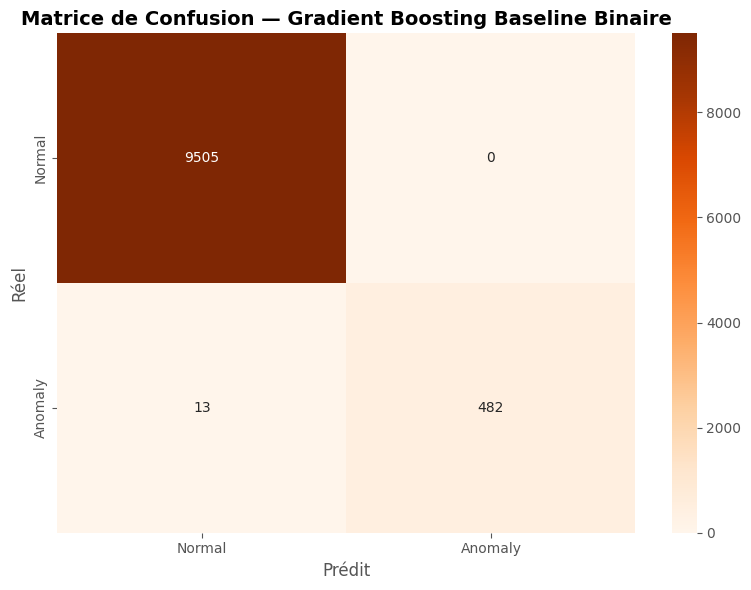

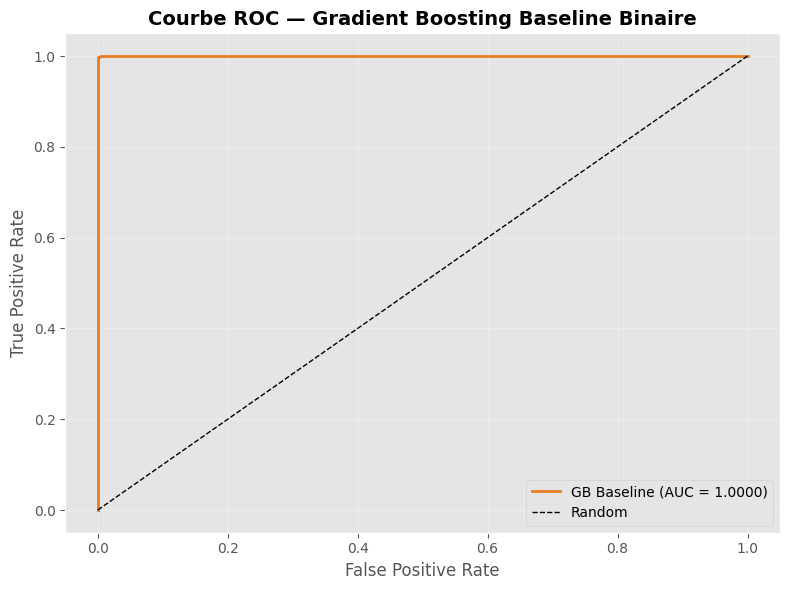

In [24]:
# =====================================================================
# 7.0.1 Gradient Boosting Baseline — Classification Binaire — SANS GridSearch
# =====================================================================
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import time

# --- Modèle Baseline avec paramètres par défaut ---
print("="*70)
print("GRADIENT BOOSTING BASELINE — CLASSIFICATION BINAIRE (Données brutes)")
print("="*70)

gb_baseline_b = GradientBoostingClassifier(random_state=42)

print(f"\nParamètres par défaut:")
print(f"   n_estimators:      {gb_baseline_b.n_estimators}")
print(f"   learning_rate:     {gb_baseline_b.learning_rate}")
print(f"   max_depth:         {gb_baseline_b.max_depth}")
print(f"   min_samples_split: {gb_baseline_b.min_samples_split}")
print(f"   min_samples_leaf:  {gb_baseline_b.min_samples_leaf}")
print(f"   subsample:         {gb_baseline_b.subsample}")

# --- Entraînement ---
start_time = time.time()
gb_baseline_b.fit(X_train_b, y1_train)
train_time = time.time() - start_time
print(f"\n✅ Entraînement terminé en {train_time:.2f}s")

# --- Prédictions ---
y1_pred_baseline = gb_baseline_b.predict(X_test_b)
y1_proba_baseline = gb_baseline_b.predict_proba(X_test_b)[:, 1]

# --- Métriques d'évaluation ---
acc_baseline = accuracy_score(y1_test, y1_pred_baseline)
prec_baseline = precision_score(y1_test, y1_pred_baseline)
rec_baseline = recall_score(y1_test, y1_pred_baseline)
f1_baseline = f1_score(y1_test, y1_pred_baseline)
auc_baseline = roc_auc_score(y1_test, y1_proba_baseline)

print(f"\n{'='*70}")
print("RÉSULTATS BASELINE — Classification Binaire (Données brutes)")
print("="*70)
print(f"\n  Accuracy:  {acc_baseline:.4f}")
print(f"  Precision: {prec_baseline:.4f}")
print(f"  Recall:    {rec_baseline:.4f}")
print(f"  F1-Score:  {f1_baseline:.4f}")
print(f"  ROC-AUC:   {auc_baseline:.4f}")

print(f"\n📊 Classification Report:")
print(classification_report(y1_test, y1_pred_baseline, target_names=['Normal', 'Anomaly']))

# --- Matrice de confusion ---
cm_baseline = confusion_matrix(y1_test, y1_pred_baseline)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('Matrice de Confusion — Gradient Boosting Baseline Binaire', fontsize=14, fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.show()

# --- Courbe ROC ---
fpr_bl, tpr_bl, _ = roc_curve(y1_test, y1_proba_baseline)

plt.figure(figsize=(8, 6))
plt.plot(fpr_bl, tpr_bl, color='#e67e22', linewidth=2, label=f'GB Baseline (AUC = {auc_baseline:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC — Gradient Boosting Baseline Binaire', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7.0 Baseline — Classification Multi-classes (Types d'anomalies)

GRADIENT BOOSTING BASELINE — CLASSIFICATION MULTI-CLASSES (Données brutes)

Paramètres par défaut:
   n_estimators:      100
   learning_rate:     0.1
   max_depth:         3
   min_samples_split: 2
   min_samples_leaf:  1



✅ Entraînement terminé en 181.52s

RÉSULTATS BASELINE — Classification Multi-classes (Données brutes)

  Accuracy:           0.9980
  Precision (weighted): 0.9980
  Recall (weighted):    0.9980
  F1-Score (weighted):  0.9980

📊 Classification Report:
                    precision    recall  f1-score   support

    backhaul_issue       0.98      0.97      0.98        64
  handover_failure       1.00      1.00      1.00        56
  hardware_failure       1.00      1.00      1.00        63
      interference       0.90      0.97      0.93        62
network_congestion       0.95      0.97      0.96        62
            normal       1.00      1.00      1.00      9505
          overload       0.97      0.92      0.94        62
   security_attack       1.00      0.98      0.99        62
signal_degradation       0.95      0.92      0.94        64

          accuracy                           1.00     10000
         macro avg       0.97      0.97      0.97     10000
      weighted avg       1

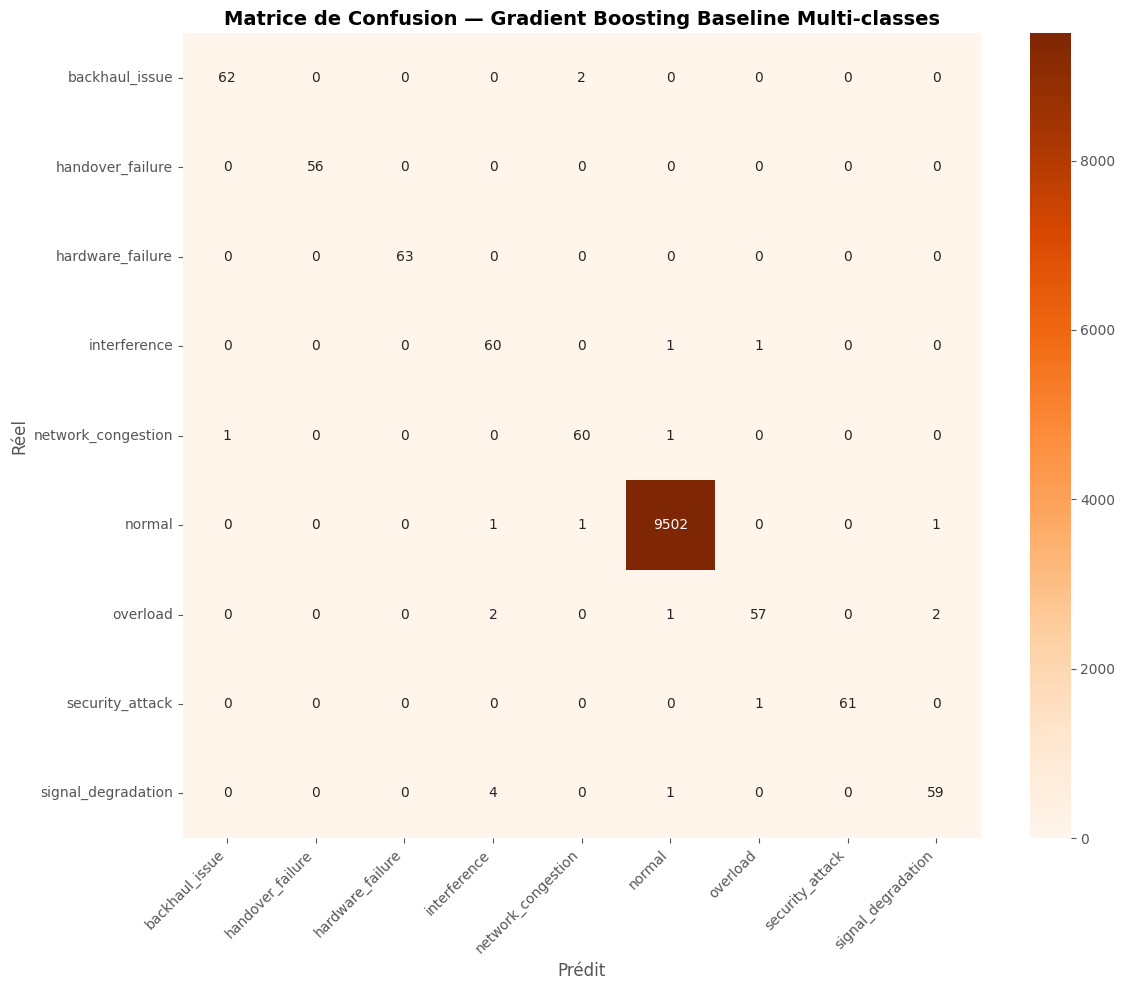


📋 RÉSUMÉ BASELINE GRADIENT BOOSTING (Paramètres par défaut)

  Métrique                     Binaire   Multi-classes
  --------------------------------------------------
  Accuracy                      0.9987          0.9980
  Precision                     1.0000          0.9980
  Recall                        0.9737          0.9980
  F1-Score                      0.9867          0.9980

⚠️  Ces résultats servent de RÉFÉRENCE pour évaluer l'amélioration
   apportée par l'optimisation des hyperparamètres (GridSearchCV).


In [25]:
# =====================================================================
# 7.0.2 Gradient Boosting Baseline — Classification Multi-classes — SANS GridSearch
# =====================================================================
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import time

# --- Modèle Baseline Multi-classes avec paramètres par défaut ---
print("="*70)
print("GRADIENT BOOSTING BASELINE — CLASSIFICATION MULTI-CLASSES (Données brutes)")
print("="*70)

gb_baseline_m = GradientBoostingClassifier(random_state=42)

print(f"\nParamètres par défaut:")
print(f"   n_estimators:      {gb_baseline_m.n_estimators}")
print(f"   learning_rate:     {gb_baseline_m.learning_rate}")
print(f"   max_depth:         {gb_baseline_m.max_depth}")
print(f"   min_samples_split: {gb_baseline_m.min_samples_split}")
print(f"   min_samples_leaf:  {gb_baseline_m.min_samples_leaf}")

# --- Entraînement ---
start_time = time.time()
gb_baseline_m.fit(X_train_m, y2_train)
train_time = time.time() - start_time
print(f"\n✅ Entraînement terminé en {train_time:.2f}s")

# --- Prédictions ---
y2_pred_baseline = gb_baseline_m.predict(X_test_m)

# --- Métriques d'évaluation ---
acc_baseline_m = accuracy_score(y2_test, y2_pred_baseline)
prec_baseline_m = precision_score(y2_test, y2_pred_baseline, average='weighted')
rec_baseline_m = recall_score(y2_test, y2_pred_baseline, average='weighted')
f1_baseline_m = f1_score(y2_test, y2_pred_baseline, average='weighted')

print(f"\n{'='*70}")
print("RÉSULTATS BASELINE — Classification Multi-classes (Données brutes)")
print("="*70)
print(f"\n  Accuracy:           {acc_baseline_m:.4f}")
print(f"  Precision (weighted): {prec_baseline_m:.4f}")
print(f"  Recall (weighted):    {rec_baseline_m:.4f}")
print(f"  F1-Score (weighted):  {f1_baseline_m:.4f}")

print(f"\n📊 Classification Report:")
print(classification_report(y2_test, y2_pred_baseline, target_names=le_anomaly.classes_))

# --- Matrice de confusion ---
cm_baseline_m = confusion_matrix(y2_test, y2_pred_baseline)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_baseline_m, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le_anomaly.classes_,
            yticklabels=le_anomaly.classes_)
plt.title('Matrice de Confusion — Gradient Boosting Baseline Multi-classes', fontsize=14, fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Résumé Baseline ---
print(f"\n{'='*70}")
print("📋 RÉSUMÉ BASELINE GRADIENT BOOSTING (Paramètres par défaut)")
print("="*70)
print(f"\n  {'Métrique':<25} {'Binaire':>10} {'Multi-classes':>15}")
print(f"  {'-'*50}")
print(f"  {'Accuracy':<25} {acc_baseline:>10.4f} {acc_baseline_m:>15.4f}")
print(f"  {'Precision':<25} {prec_baseline:>10.4f} {prec_baseline_m:>15.4f}")
print(f"  {'Recall':<25} {rec_baseline:>10.4f} {rec_baseline_m:>15.4f}")
print(f"  {'F1-Score':<25} {f1_baseline:>10.4f} {f1_baseline_m:>15.4f}")
print(f"\n⚠️  Ces résultats servent de RÉFÉRENCE pour évaluer l'amélioration")
print(f"   apportée par l'optimisation des hyperparamètres (GridSearchCV).")

## 4. Modeling — Gradient Boosting (Raw Data)
Training the **Gradient Boosting** model on raw data (without normalization). Gradient Boosting, like decision trees, does not require normalization because it relies on split thresholds, not on distances.

### 4.1 Binary Classification — Gradient Boosting (Normal vs Anomaly)

In [26]:
# =====================================================================
# 4.1.1 Gradient Boosting — Binary Classification (Default Parameters)
# =====================================================================
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import time

print("="*70)
print("GRADIENT BOOSTING — CLASSIFICATION BINAIRE (Normal vs Anomaly)")
print("="*70)

# Train the model with default parameters
start_time = time.time()
gb_binary = GradientBoostingClassifier(random_state=42)
gb_binary.fit(X_train_b, y1_train)
train_time = time.time() - start_time

# Predictions
start_pred = time.time()
y1_pred = gb_binary.predict(X_test_b)
y1_pred_proba = gb_binary.predict_proba(X_test_b)[:, 1]
pred_time = time.time() - start_pred

# Metrics
acc = accuracy_score(y1_test, y1_pred)
prec = precision_score(y1_test, y1_pred)
rec = recall_score(y1_test, y1_pred)
f1 = f1_score(y1_test, y1_pred)
roc_auc = roc_auc_score(y1_test, y1_pred_proba)

print(f"\n⏱️  Training time:   {train_time:.4f}s")
print(f"⏱️  Prediction time: {pred_time:.4f}s")
print(f"\n📊 METRICS (Default Parameters):")
print(f"   Accuracy:  {acc:.4f}  ({acc*100:.2f}%)")
print(f"   Precision: {prec:.4f}")
print(f"   Recall:    {rec:.4f}")
print(f"   F1-Score:  {f1:.4f}")
print(f"   ROC-AUC:   {roc_auc:.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(y1_test, y1_pred, target_names=['Normal', 'Anomaly']))

# Model characteristics
print(f"\n🌲 Model Characteristics:")
print(f"   Number of estimators: {gb_binary.n_estimators}")
print(f"   Learning rate:        {gb_binary.learning_rate}")
print(f"   Max depth:            {gb_binary.max_depth}")
print(f"   Number of features:   {gb_binary.n_features_in_}")

GRADIENT BOOSTING — CLASSIFICATION BINAIRE (Normal vs Anomaly)

⏱️  Training time:   19.9631s
⏱️  Prediction time: 0.0129s

📊 METRICS (Default Parameters):
   Accuracy:  0.9987  (99.87%)
   Precision: 1.0000
   Recall:    0.9737
   F1-Score:  0.9867
   ROC-AUC:   1.0000

📋 Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      9505
     Anomaly       1.00      0.97      0.99       495

    accuracy                           1.00     10000
   macro avg       1.00      0.99      0.99     10000
weighted avg       1.00      1.00      1.00     10000


🌲 Model Characteristics:
   Number of estimators: 100
   Learning rate:        0.1
   Max depth:            3
   Number of features:   23


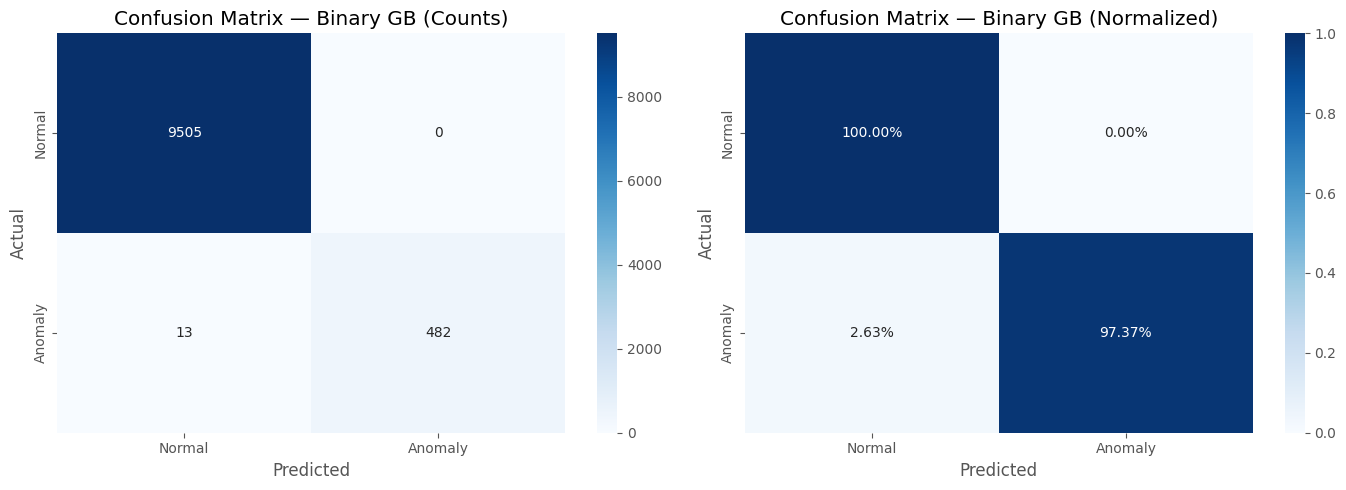


True Negatives  (TN) : 9505
False Positives (FP) : 0
False Negatives (FN) : 13
True Positives  (TP) : 482

False Positive Rate (FPR) : 0.0000
False Negative Rate (FNR) : 0.0263


In [27]:
# ── 4.1.2  Confusion Matrix — Binary Gradient Boosting (Default) ──

from sklearn.metrics import confusion_matrix

cm_gb_b = confusion_matrix(y1_test, y1_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count-based matrix
sns.heatmap(cm_gb_b, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'], ax=axes[0])
axes[0].set_title('Confusion Matrix — Binary GB (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Normalized matrix
cm_gb_b_norm = cm_gb_b.astype('float') / cm_gb_b.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_gb_b_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'], ax=axes[1])
axes[1].set_title('Confusion Matrix — Binary GB (Normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Extract TP, TN, FP, FN
tn, fp, fn, tp = cm_gb_b.ravel()
print(f"\nTrue Negatives  (TN) : {tn}")
print(f"False Positives (FP) : {fp}")
print(f"False Negatives (FN) : {fn}")
print(f"True Positives  (TP) : {tp}")
print(f"\nFalse Positive Rate (FPR) : {fp/(fp+tn):.4f}")
print(f"False Negative Rate (FNR) : {fn/(fn+tp):.4f}")

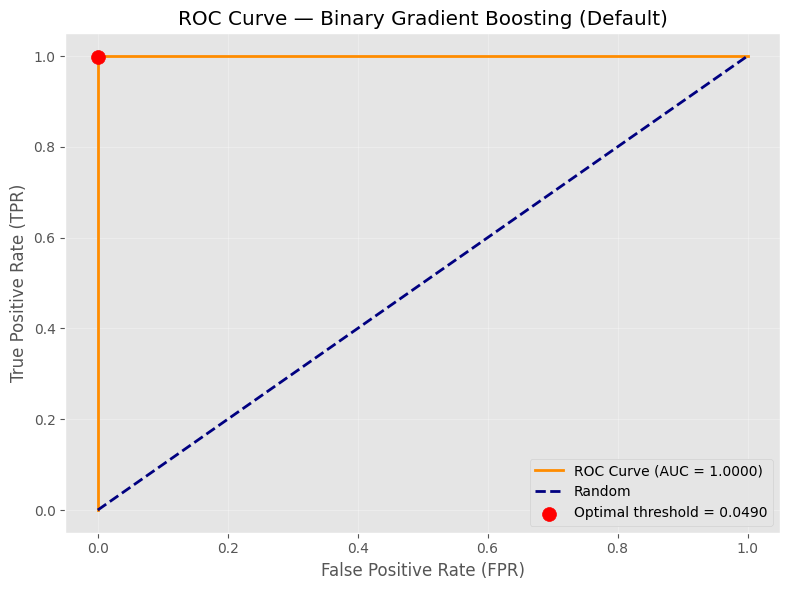

Optimal threshold (Youden's J) : 0.0490
TPR at optimal threshold       : 0.9980
FPR at optimal threshold       : 0.0007


In [28]:
# ── 4.1.3  ROC Curve — Binary Gradient Boosting (Default) ──

from sklearn.metrics import roc_curve, auc

y1_proba_b = gb_binary.predict_proba(X_test_b)[:, 1]
fpr, tpr, thresholds = roc_curve(y1_test, y1_proba_b)
roc_auc = auc(fpr, tpr)

# Optimal threshold (Youden's J)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.scatter(fpr[best_idx], tpr[best_idx], color='red', s=100, zorder=5,
            label=f'Optimal threshold = {best_threshold:.4f}')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve — Binary Gradient Boosting (Default)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal threshold (Youden's J) : {best_threshold:.4f}")
print(f"TPR at optimal threshold       : {tpr[best_idx]:.4f}")
print(f"FPR at optimal threshold       : {fpr[best_idx]:.4f}")

In [29]:
# ── 4.1.4  Cross-Validation — Binary Gradient Boosting (Default) ──

from sklearn.model_selection import cross_val_score

print("5-Fold Cross-Validation — Binary Gradient Boosting (Default)")
print("=" * 65)

scoring_metrics = ['accuracy', 'f1', 'roc_auc']
cv_results_gb_b = {}

for metric in scoring_metrics:
    scores = cross_val_score(gb_binary, X_train_b, y1_train,
                             cv=5, scoring=metric, n_jobs=-1)
    cv_results_gb_b[metric] = scores
    print(f"\n{metric.upper()}:")
    print(f"  Scores per fold : {scores.round(4)}")
    print(f"  Mean ± Std      : {scores.mean():.4f} ± {scores.std():.4f}")

print("\n" + "=" * 65)
print("Cross-Validation Summary:")
for metric, scores in cv_results_gb_b.items():
    print(f"  {metric:>10s} : {scores.mean():.4f} ± {scores.std():.4f}")

5-Fold Cross-Validation — Binary Gradient Boosting (Default)

ACCURACY:
  Scores per fold : [0.9996 0.9991 0.9991 0.9978 0.9989]
  Mean ± Std      : 0.9989 ± 0.0006

F1:
  Scores per fold : [0.9962 0.9911 0.9911 0.9767 0.9886]
  Mean ± Std      : 0.9887 ± 0.0065

ROC_AUC:
  Scores per fold : [0.9997 0.9999 1.     1.     1.    ]
  Mean ± Std      : 0.9999 ± 0.0001

Cross-Validation Summary:
    accuracy : 0.9989 ± 0.0006
          f1 : 0.9887 ± 0.0065
     roc_auc : 0.9999 ± 0.0001


### 4.2 Hyperparameter Tuning — Binary Gradient Boosting (GridSearchCV)

In [30]:
# ── 4.2.1  GridSearchCV — Binary Gradient Boosting ──

from sklearn.model_selection import GridSearchCV
import time

param_grid_gb_b = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.8, 1.0]
}

print("GridSearchCV — Binary Gradient Boosting")
print("=" * 55)
total_combos = 1
for k, v in param_grid_gb_b.items():
    total_combos *= len(v)
    print(f"  {k}: {v}")
print(f"\nTotal number of combinations : {total_combos}")
print(f"With 3-fold CV : {total_combos * 3} fits")
print("\n⏳ Training in progress (this may take several minutes)...")

start_time = time.time()

grid_search_gb_b = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid_gb_b,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_gb_b.fit(X_train_b, y1_train)

elapsed = time.time() - start_time
print(f"\n✅ GridSearchCV completed in {elapsed:.1f} seconds ({elapsed/60:.1f} minutes)")

print(f"\nBest hyperparameters:")
for param, value in grid_search_gb_b.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest F1 score (CV) : {grid_search_gb_b.best_score_:.4f}")

GridSearchCV — Binary Gradient Boosting
  n_estimators: [100, 200, 300]
  learning_rate: [0.01, 0.05, 0.1, 0.2]
  max_depth: [3, 5, 7]
  min_samples_split: [2, 5, 10]
  subsample: [0.8, 1.0]

Total number of combinations : 216
With 3-fold CV : 648 fits

⏳ Training in progress (this may take several minutes)...
Fitting 3 folds for each of 216 candidates, totalling 648 fits

✅ GridSearchCV completed in 2713.2 seconds (45.2 minutes)

Best hyperparameters:
  learning_rate: 0.1
  max_depth: 7
  min_samples_split: 2
  n_estimators: 300
  subsample: 0.8

Best F1 score (CV) : 0.9990


In [31]:
# ── 4.2.2  Optimized Model Evaluation — Binary GB ──
gb_binary_best = grid_search_gb_b.best_estimator_

y1_pred_b_opt = gb_binary_best.predict(X_test_b)
y1_proba_b_opt = gb_binary_best.predict_proba(X_test_b)[:, 1]

acc_opt = accuracy_score(y1_test, y1_pred_b_opt)
prec_opt = precision_score(y1_test, y1_pred_b_opt)
rec_opt = recall_score(y1_test, y1_pred_b_opt)
f1_opt = f1_score(y1_test, y1_pred_b_opt)
roc_opt = roc_auc_score(y1_test, y1_proba_b_opt)

print("=" * 70)
print("COMPARISON: Binary Gradient Boosting — Default vs Optimized")
print("=" * 70)

# Default model metrics
acc_def = accuracy_score(y1_test, y1_pred)
prec_def = precision_score(y1_test, y1_pred)
rec_def = recall_score(y1_test, y1_pred)
f1_def = f1_score(y1_test, y1_pred)
roc_def = roc_auc_score(y1_test, y1_proba_b)

metrics_comparison = {
    'Accuracy':  (acc_def, acc_opt),
    'Precision': (prec_def, prec_opt),
    'Recall':    (rec_def, rec_opt),
    'F1-Score':  (f1_def, f1_opt),
    'ROC-AUC':   (roc_def, roc_opt)
}

print(f"{'Metric':<12} {'Default':>10} {'Optimized':>10} {'Δ':>10}")
print("-" * 45)
for metric, (default, optimized) in metrics_comparison.items():
    delta = optimized - default
    arrow = "↑" if delta > 0 else ("↓" if delta < 0 else "=")
    print(f"{metric:<12} {default:>10.4f} {optimized:>10.4f} {delta:>+10.4f} {arrow}")

print("\n" + "=" * 70)
print("\nClassification Report (Optimized):")
print(classification_report(y1_test, y1_pred_b_opt, target_names=['Normal', 'Anomaly']))

COMPARISON: Binary Gradient Boosting — Default vs Optimized
Metric          Default  Optimized          Δ
---------------------------------------------
Accuracy         0.9987     0.9997    +0.0010 ↑
Precision        1.0000     0.9960    -0.0040 ↓
Recall           0.9737     0.9980    +0.0242 ↑
F1-Score         0.9867     0.9970    +0.0103 ↑
ROC-AUC          1.0000     1.0000    +0.0000 ↑


Classification Report (Optimized):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      9505
     Anomaly       1.00      1.00      1.00       495

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



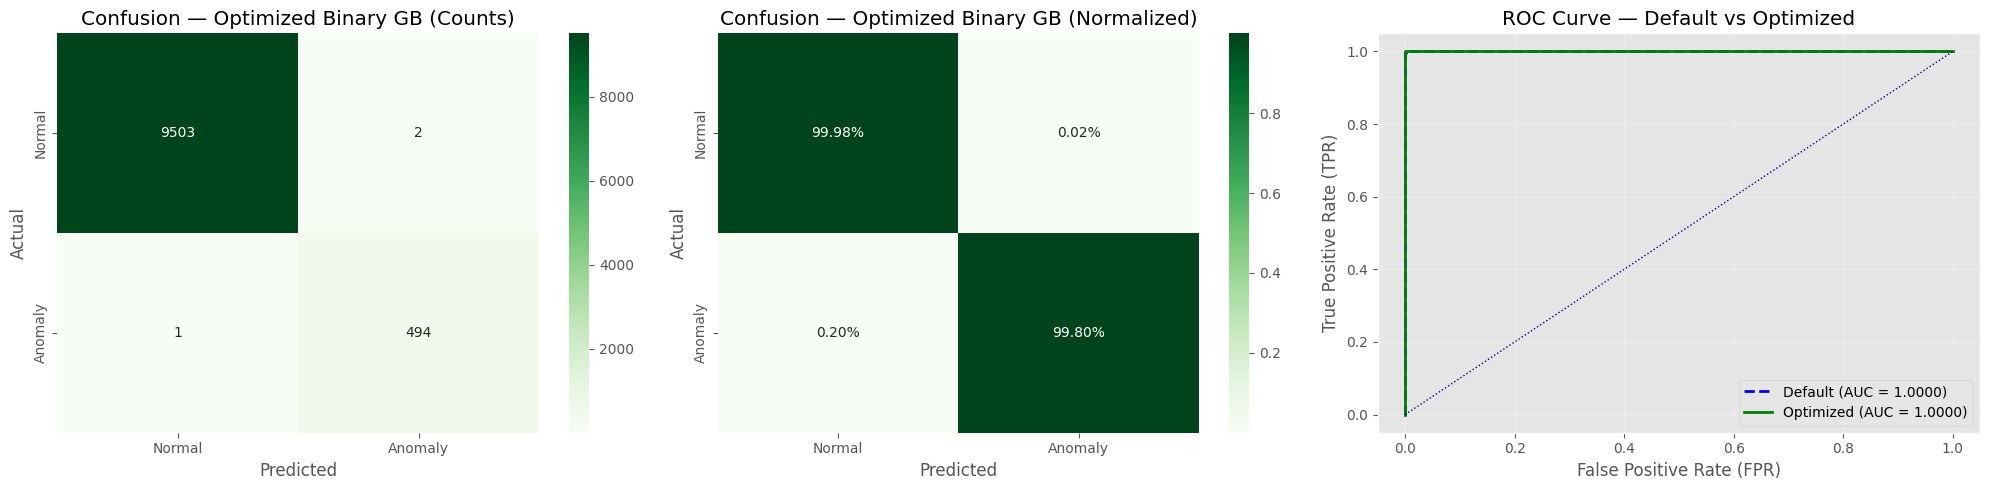

Default   → TN=9505, FP=0, FN=13, TP=482
Optimized → TN=9503, FP=2, FN=1, TP=494


In [32]:
# ── 4.2.3  Confusion Matrix + ROC Curve — Optimized Binary GB ──

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Confusion matrix (counts)
cm_gb_b_opt = confusion_matrix(y1_test, y1_pred_b_opt)
sns.heatmap(cm_gb_b_opt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'], ax=axes[0])
axes[0].set_title('Confusion — Optimized Binary GB (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# 2. Confusion matrix (normalized)
cm_gb_b_opt_norm = cm_gb_b_opt.astype('float') / cm_gb_b_opt.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_gb_b_opt_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'], ax=axes[1])
axes[1].set_title('Confusion — Optimized Binary GB (Normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# 3. ROC curve comparison
fpr_opt, tpr_opt, thresholds_opt = roc_curve(y1_test, y1_proba_b_opt)
roc_auc_opt = auc(fpr_opt, tpr_opt)

axes[2].plot(fpr, tpr, color='blue', lw=2, linestyle='--',
             label=f'Default (AUC = {roc_auc:.4f})')
axes[2].plot(fpr_opt, tpr_opt, color='green', lw=2,
             label=f'Optimized (AUC = {roc_auc_opt:.4f})')
axes[2].plot([0, 1], [0, 1], color='navy', lw=1, linestyle=':')
axes[2].set_xlabel('False Positive Rate (FPR)')
axes[2].set_ylabel('True Positive Rate (TPR)')
axes[2].set_title('ROC Curve — Default vs Optimized')
axes[2].legend(loc='lower right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# TN, FP, FN, TP comparison
tn_o, fp_o, fn_o, tp_o = cm_gb_b_opt.ravel()
print(f"Default   → TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Optimized → TN={tn_o}, FP={fp_o}, FN={fn_o}, TP={tp_o}")

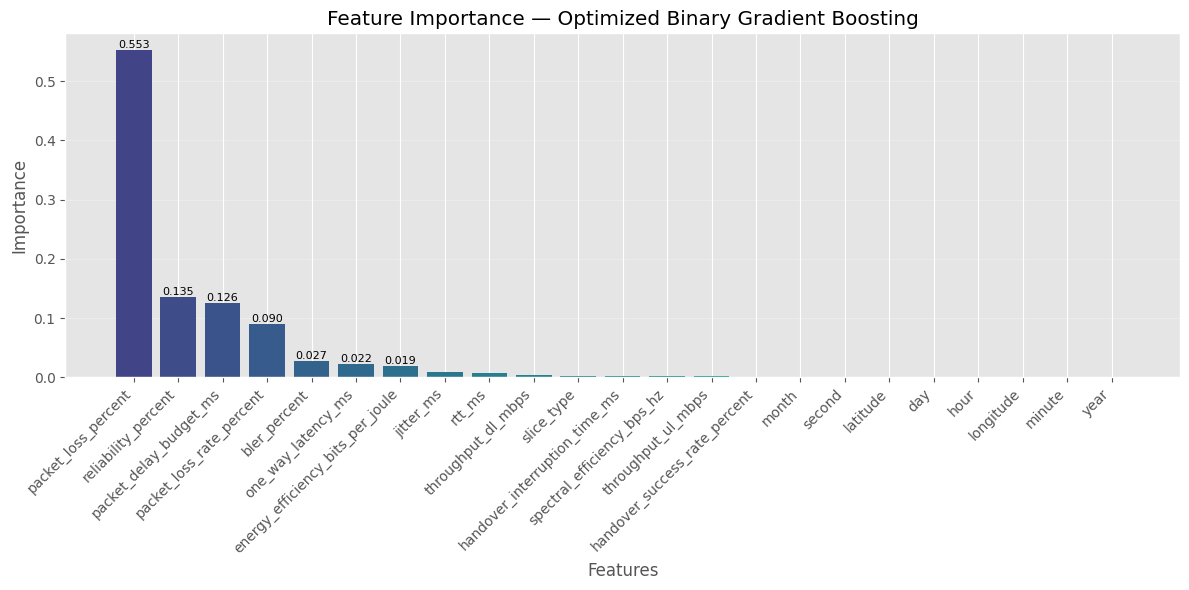

Top 10 Features — Optimized Binary GB:
----------------------------------------
   1. packet_loss_percent       : 0.5530
   2. reliability_percent       : 0.1350
   3. packet_delay_budget_ms    : 0.1257
   4. packet_loss_rate_percent  : 0.0896
   5. bler_percent              : 0.0267
   6. one_way_latency_ms        : 0.0225
   7. energy_efficiency_bits_per_joule : 0.0190
   8. jitter_ms                 : 0.0088
   9. rtt_ms                    : 0.0066
  10. throughput_dl_mbps        : 0.0035


In [33]:
# ── 4.2.4  Feature Importance — Optimized Binary GB ──

feature_names = X_train_b.columns
importances_gb_b = gb_binary_best.feature_importances_

# Sort by descending importance
indices_gb_b = np.argsort(importances_gb_b)[::-1]

plt.figure(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(feature_names)))
bars = plt.bar(range(len(feature_names)),
               importances_gb_b[indices_gb_b],
               color=colors)
plt.xticks(range(len(feature_names)),
           feature_names[indices_gb_b], rotation=45, ha='right')
plt.title('Feature Importance — Optimized Binary Gradient Boosting')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.grid(axis='y', alpha=0.3)

# Add values on bars
for bar, val in zip(bars, importances_gb_b[indices_gb_b]):
    if val > 0.01:
        plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Top 10 features
print("Top 10 Features — Optimized Binary GB:")
print("-" * 40)
for i in range(min(10, len(feature_names))):
    idx = indices_gb_b[i]
    print(f"  {i+1:2d}. {feature_names[idx]:<25s} : {importances_gb_b[idx]:.4f}")

### 4.3 Multi-Class Classification — Gradient Boosting

In [34]:
# ── 4.3.1  Multi-Class Gradient Boosting — Default Parameters ──

print("=" * 70)
print("GRADIENT BOOSTING — MULTI-CLASS CLASSIFICATION (Default Parameters)")
print("=" * 70)

gb_multi = GradientBoostingClassifier(random_state=42)

start_time = time.time()
gb_multi.fit(X_train_m, y2_train)
train_time_m = time.time() - start_time

y2_pred_m = gb_multi.predict(X_test_m)

# Metrics
acc_m = accuracy_score(y2_test, y2_pred_m)
prec_m = precision_score(y2_test, y2_pred_m, average='weighted')
rec_m = recall_score(y2_test, y2_pred_m, average='weighted')
f1_m = f1_score(y2_test, y2_pred_m, average='weighted')

print(f"\nTraining time: {train_time_m:.1f}s")
print(f"\n{'Metric':<20} {'Value':>10}")
print("-" * 32)
print(f"{'Accuracy':<20} {acc_m:>10.4f}")
print(f"{'Precision (weighted)':<20} {prec_m:>10.4f}")
print(f"{'Recall (weighted)':<20} {rec_m:>10.4f}")
print(f"{'F1-Score (weighted)':<20} {f1_m:>10.4f}")

# Class names
class_names = [str(c) for c in sorted(np.unique(y2_test))]
print(f"\nNumber of classes: {len(class_names)}")
print(f"Classes: {class_names}")

print("\nClassification Report:")
print(classification_report(y2_test, y2_pred_m, target_names=class_names))

GRADIENT BOOSTING — MULTI-CLASS CLASSIFICATION (Default Parameters)

Training time: 180.0s

Metric                    Value
--------------------------------
Accuracy                 0.9980
Precision (weighted)     0.9980
Recall (weighted)        0.9980
F1-Score (weighted)      0.9980

Number of classes: 9
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8']

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98        64
           1       1.00      1.00      1.00        56
           2       1.00      1.00      1.00        63
           3       0.90      0.97      0.93        62
           4       0.95      0.97      0.96        62
           5       1.00      1.00      1.00      9505
           6       0.97      0.92      0.94        62
           7       1.00      0.98      0.99        62
           8       0.95      0.92      0.94        64

    accuracy                           1.00     10000
   macro avg      

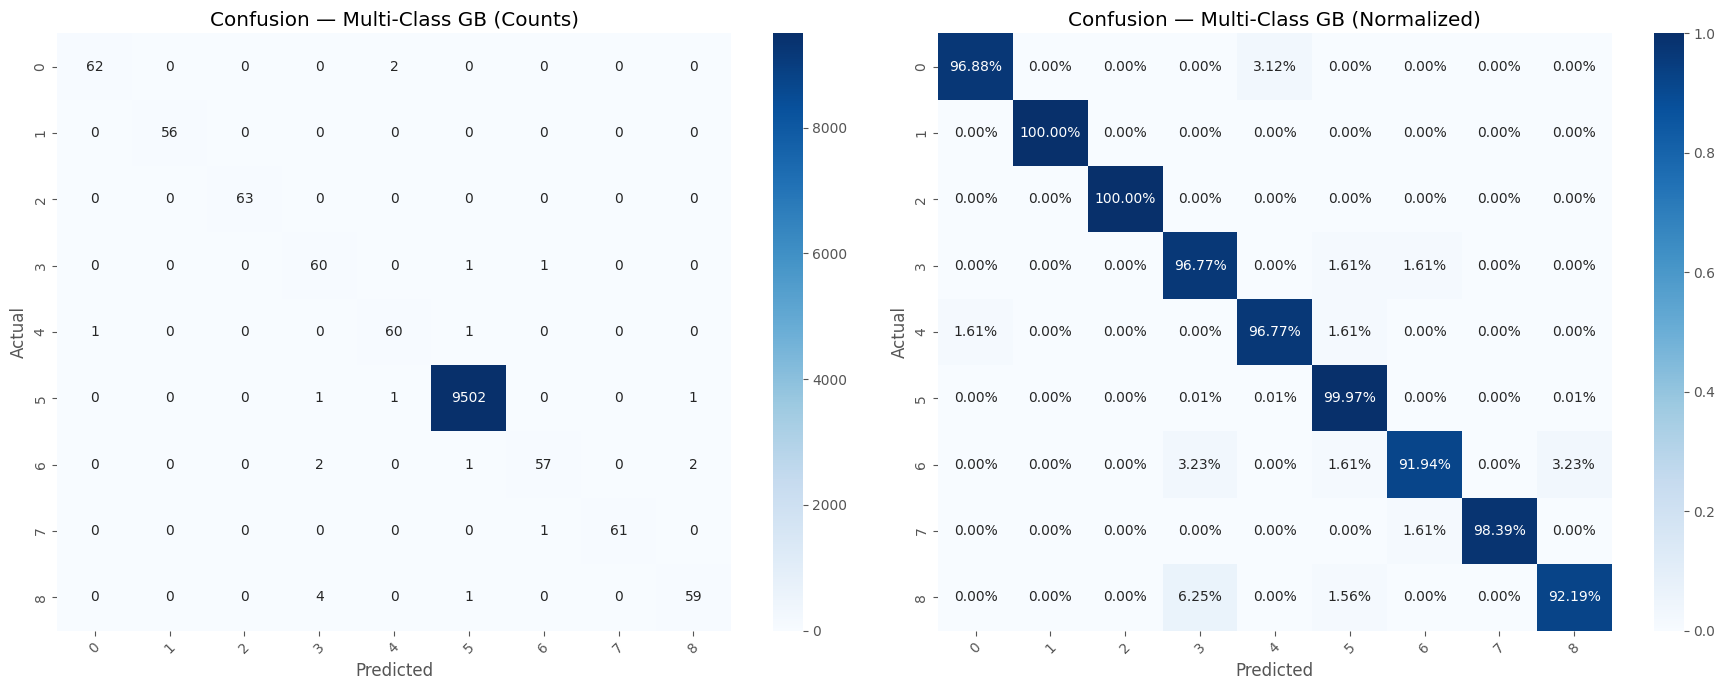

Per-class accuracy (normalized diagonal):
---------------------------------------------
  0                         : 96.88%
  1                         : 100.00%
  2                         : 100.00%
  3                         : 96.77%
  4                         : 96.77%
  5                         : 99.97%
  6                         : 91.94%
  7                         : 98.39%
  8                         : 92.19%


In [35]:
# ── 4.3.2  Confusion Matrix — Multi-Class GB (Default) ──

cm_gb_m = confusion_matrix(y2_test, y2_pred_m)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Count-based matrix
sns.heatmap(cm_gb_m, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion — Multi-Class GB (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=45)

# Normalized matrix
cm_gb_m_norm = cm_gb_m.astype('float') / cm_gb_m.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_gb_m_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion — Multi-Class GB (Normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Per-class accuracy
print("Per-class accuracy (normalized diagonal):")
print("-" * 45)
for i, cls in enumerate(class_names):
    print(f"  {cls:<25s} : {cm_gb_m_norm[i, i]:.2%}")

### 4.4 Hyperparameter Tuning — Multi-Class Gradient Boosting (GridSearchCV)

In [36]:
# ── 4.4.1  GridSearchCV — Multi-Class Gradient Boosting ──

param_grid_gb_m = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.8, 1.0]
}

print("GridSearchCV — Multi-Class Gradient Boosting")
print("=" * 55)
total_combos_m = 1
for k, v in param_grid_gb_m.items():
    total_combos_m *= len(v)
    print(f"  {k}: {v}")
print(f"\nTotal number of combinations: {total_combos_m}")
print(f"With 3-fold CV: {total_combos_m * 3} fits")
print("\n⏳ Training in progress (this may take several minutes)...")

start_time = time.time()

grid_search_gb_m = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid_gb_m,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search_gb_m.fit(X_train_m, y2_train)

elapsed_m = time.time() - start_time
print(f"\n✅ GridSearchCV completed in {elapsed_m:.1f} seconds ({elapsed_m/60:.1f} minutes)")

print(f"\nBest hyperparameters:")
for param, value in grid_search_gb_m.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest F1 weighted score (CV): {grid_search_gb_m.best_score_:.4f}")

GridSearchCV — Multi-Class Gradient Boosting
  n_estimators: [100, 200, 300]
  learning_rate: [0.01, 0.05, 0.1, 0.2]
  max_depth: [3, 5, 7]
  min_samples_split: [2, 5, 10]
  subsample: [0.8, 1.0]

Total number of combinations: 216
With 3-fold CV: 648 fits

⏳ Training in progress (this may take several minutes)...
Fitting 3 folds for each of 216 candidates, totalling 648 fits

✅ GridSearchCV completed in 19989.3 seconds (333.2 minutes)

Best hyperparameters:
  learning_rate: 0.05
  max_depth: 3
  min_samples_split: 5
  n_estimators: 300
  subsample: 1.0

Best F1 weighted score (CV): 0.9990


In [37]:
# ── 4.4.2  Optimized Model Evaluation — Multi-Class GB ──

gb_multi_best = grid_search_gb_m.best_estimator_

y2_pred_m_opt = gb_multi_best.predict(X_test_m)

acc_m_opt = accuracy_score(y2_test, y2_pred_m_opt)
prec_m_opt = precision_score(y2_test, y2_pred_m_opt, average='weighted')
rec_m_opt = recall_score(y2_test, y2_pred_m_opt, average='weighted')
f1_m_opt = f1_score(y2_test, y2_pred_m_opt, average='weighted')

print("=" * 70)
print("COMPARISON: Multi-Class GB — Default vs Optimized")
print("=" * 70)

metrics_comp_m = {
    'Accuracy':           (acc_m, acc_m_opt),
    'Precision (weighted)':(prec_m, prec_m_opt),
    'Recall (weighted)':  (rec_m, rec_m_opt),
    'F1-Score (weighted)':(f1_m, f1_m_opt)
}

print(f"{'Metric':<22} {'Default':>10} {'Optimized':>10} {'Δ':>10}")
print("-" * 55)
for metric, (default, optimized) in metrics_comp_m.items():
    delta = optimized - default
    arrow = "↑" if delta > 0 else ("↓" if delta < 0 else "=")
    print(f"{metric:<22} {default:>10.4f} {optimized:>10.4f} {delta:>+10.4f} {arrow}")

print("\nClassification Report (Optimized):")
print(classification_report(y2_test, y2_pred_m_opt, target_names=class_names))

COMPARISON: Multi-Class GB — Default vs Optimized
Metric                    Default  Optimized          Δ
-------------------------------------------------------
Accuracy                   0.9980     0.9997    +0.0017 ↑
Precision (weighted)       0.9980     0.9997    +0.0017 ↑
Recall (weighted)          0.9980     0.9997    +0.0017 ↑
F1-Score (weighted)        0.9980     0.9997    +0.0017 ↑

Classification Report (Optimized):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        64
           1       1.00      1.00      1.00        56
           2       1.00      1.00      1.00        63
           3       1.00      0.98      0.99        62
           4       0.98      1.00      0.99        62
           5       1.00      1.00      1.00      9505
           6       1.00      0.98      0.99        62
           7       1.00      1.00      1.00        62
           8       1.00      1.00      1.00        64

    accuracy                

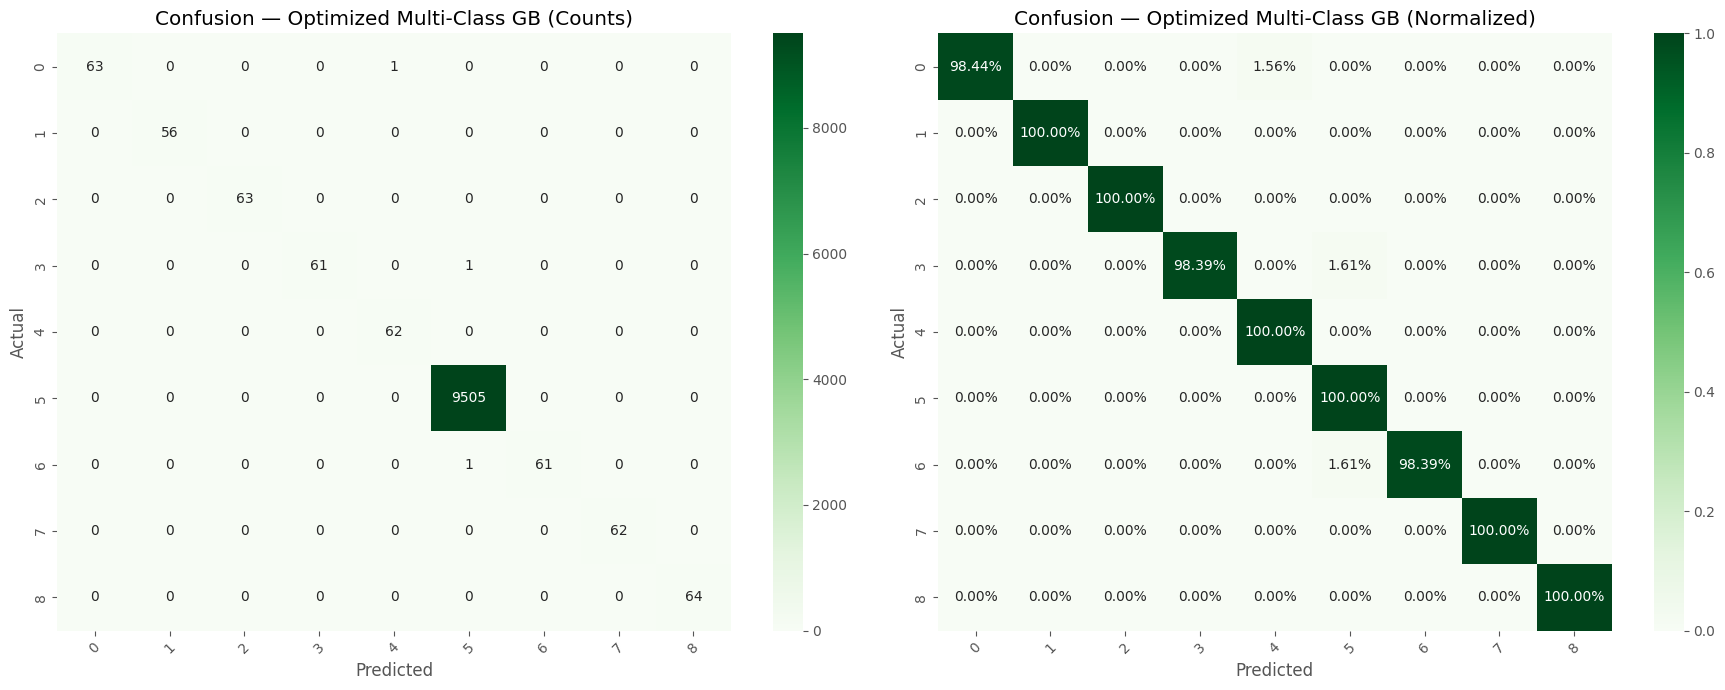

Per-class accuracy — Default vs Optimized:
-------------------------------------------------------
Class                        Default  Optimized        Δ
-------------------------------------------------------
  0                           96.88%     98.44%   +1.56% ↑
  1                          100.00%    100.00%   +0.00% =
  2                          100.00%    100.00%   +0.00% =
  3                           96.77%     98.39%   +1.61% ↑
  4                           96.77%    100.00%   +3.23% ↑
  5                           99.97%    100.00%   +0.03% ↑
  6                           91.94%     98.39%   +6.45% ↑
  7                           98.39%    100.00%   +1.61% ↑
  8                           92.19%    100.00%   +7.81% ↑


In [38]:
# ── 4.4.3  Confusion Matrix — Optimized Multi-Class GB ──

cm_gb_m_opt = confusion_matrix(y2_test, y2_pred_m_opt)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Counts
sns.heatmap(cm_gb_m_opt, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion — Optimized Multi-Class GB (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=45)

# Normalized
cm_gb_m_opt_norm = cm_gb_m_opt.astype('float') / cm_gb_m_opt.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_gb_m_opt_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion — Optimized Multi-Class GB (Normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Per-class accuracy comparison
print("Per-class accuracy — Default vs Optimized:")
print("-" * 55)
print(f"{'Class':<25s} {'Default':>10s} {'Optimized':>10s} {'Δ':>8s}")
print("-" * 55)
for i, cls in enumerate(class_names):
    def_val = cm_gb_m_norm[i, i]
    opt_val = cm_gb_m_opt_norm[i, i]
    delta = opt_val - def_val
    arrow = "↑" if delta > 0 else ("↓" if delta < 0 else "=")
    print(f"  {cls:<23s} {def_val:>10.2%} {opt_val:>10.2%} {delta:>+8.2%} {arrow}")

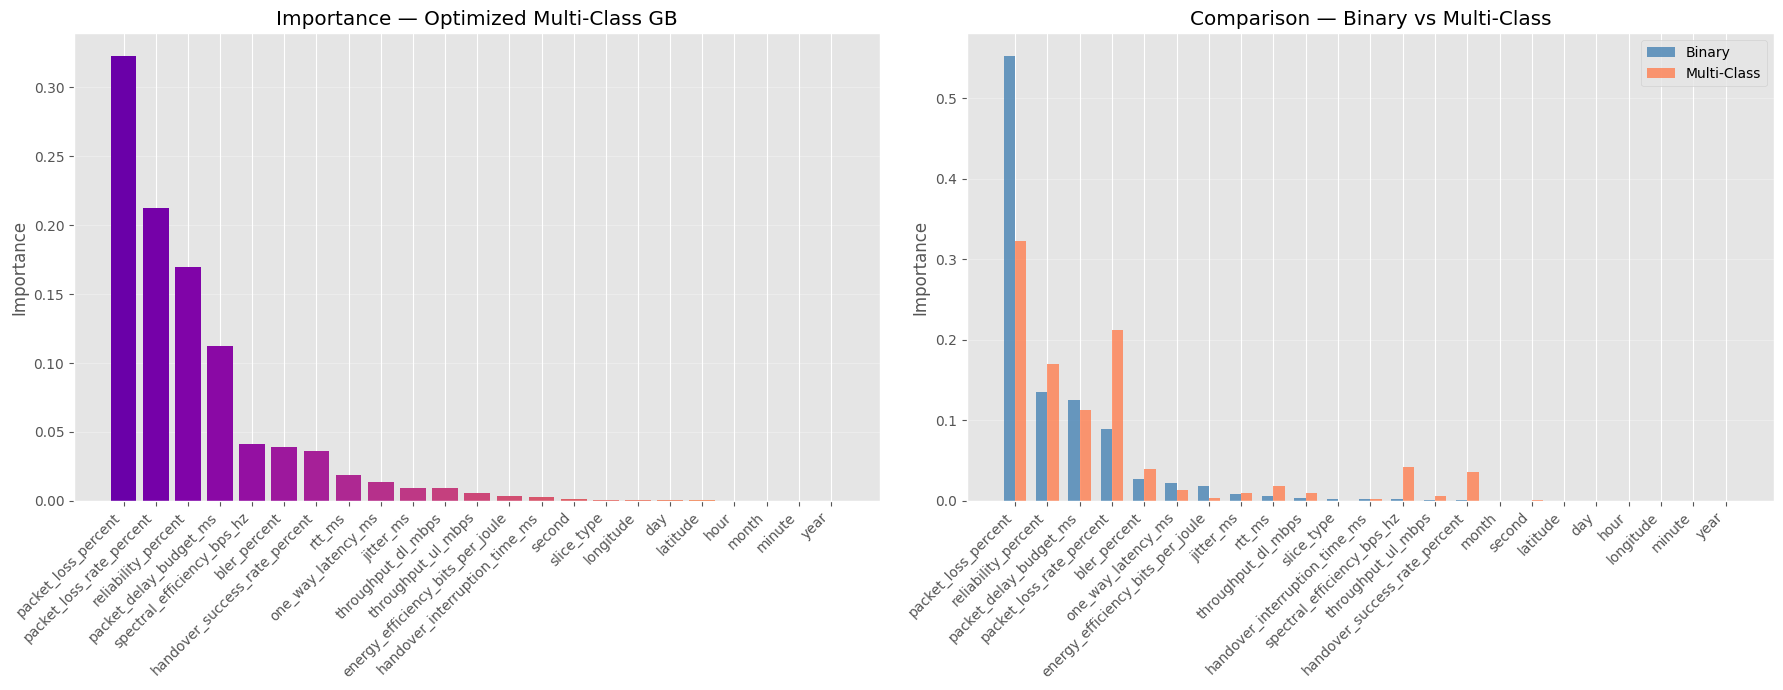

Top 10 Features — Optimized Multi-Class GB:
----------------------------------------
   1. packet_loss_percent       : 0.3231
   2. packet_loss_rate_percent  : 0.2124
   3. reliability_percent       : 0.1696
   4. packet_delay_budget_ms    : 0.1127
   5. spectral_efficiency_bps_hz : 0.0415
   6. bler_percent              : 0.0390
   7. handover_success_rate_percent : 0.0361
   8. rtt_ms                    : 0.0184
   9. one_way_latency_ms        : 0.0138
  10. jitter_ms                 : 0.0095


In [39]:
# ── 4.4.4  Feature Importance — Multi-Class GB (+ Comparison) ──

importances_gb_m = gb_multi_best.feature_importances_
indices_gb_m = np.argsort(importances_gb_m)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Feature importance — Multi-Class
colors_m = plt.cm.plasma(np.linspace(0.2, 0.8, len(feature_names)))
bars_m = axes[0].bar(range(len(feature_names)),
                     importances_gb_m[indices_gb_m], color=colors_m)
axes[0].set_xticks(range(len(feature_names)))
axes[0].set_xticklabels(feature_names[indices_gb_m], rotation=45, ha='right')
axes[0].set_title('Importance — Optimized Multi-Class GB')
axes[0].set_ylabel('Importance')
axes[0].grid(axis='y', alpha=0.3)

# Comparison Binary vs Multi-Class
x_pos = np.arange(len(feature_names))
width = 0.35
axes[1].bar(x_pos - width/2, importances_gb_b[indices_gb_b], width,
            label='Binary', color='steelblue', alpha=0.8)
axes[1].bar(x_pos + width/2, importances_gb_m[indices_gb_b], width,
            label='Multi-Class', color='coral', alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(feature_names[indices_gb_b], rotation=45, ha='right')
axes[1].set_title('Comparison — Binary vs Multi-Class')
axes[1].set_ylabel('Importance')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Top 10 features Multi-Class
print("Top 10 Features — Optimized Multi-Class GB:")
print("-" * 40)
for i in range(min(10, len(feature_names))):
    idx = indices_gb_m[i]
    print(f"  {i+1:2d}. {feature_names[idx]:<25s} : {importances_gb_m[idx]:.4f}")

### 4.5 Overfitting Analysis — Gradient Boosting

OVERFITTING ANALYSIS — GRADIENT BOOSTING

Model                      Train Acc   Test Acc    Δ Acc   Train F1    Test F1     Δ F1
-------------------------------------------------------------------------------------
GB Binary (opt.)              1.0000     0.9997  +0.0003     1.0000     0.9970  +0.0030
GB Multi-Class (opt.)         1.0000     0.9997  +0.0003     1.0000     0.9997  +0.0003


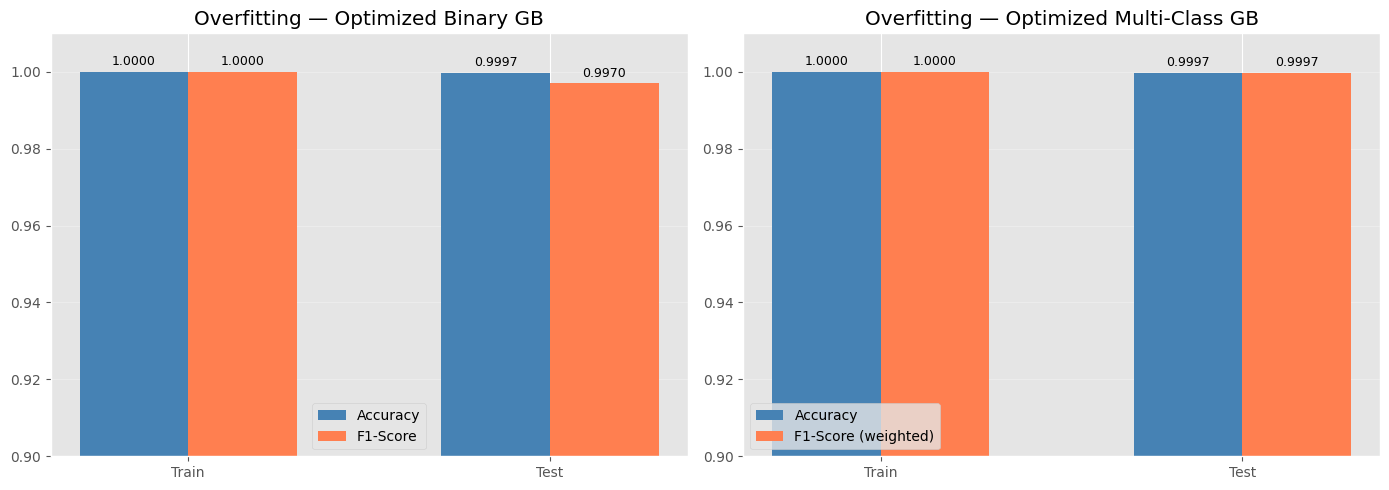


📊 Interpretation:
  ✅ GB Binary: No significant overfitting (Δ Accuracy=+0.0003, Δ F1=+0.0030)
  ✅ GB Multi-Class: No significant overfitting (Δ Accuracy=+0.0003, Δ F1=+0.0003)


In [40]:
# ── 4.5.1  Overfitting Analysis — Train vs Test ──

print("=" * 75)
print("OVERFITTING ANALYSIS — GRADIENT BOOSTING")
print("=" * 75)

# ── Optimized Binary ──
y1_train_pred = gb_binary_best.predict(X_train_b)
y1_test_pred = gb_binary_best.predict(X_test_b)

train_acc_b = accuracy_score(y1_train, y1_train_pred)
test_acc_b = accuracy_score(y1_test, y1_test_pred)
train_f1_b = f1_score(y1_train, y1_train_pred)
test_f1_b = f1_score(y1_test, y1_test_pred)

# ── Optimized Multi-Class ──
y2_train_pred = gb_multi_best.predict(X_train_m)
y2_test_pred = gb_multi_best.predict(X_test_m)

train_acc_m = accuracy_score(y2_train, y2_train_pred)
test_acc_m = accuracy_score(y2_test, y2_test_pred)
train_f1_m = f1_score(y2_train, y2_train_pred, average='weighted')
test_f1_m = f1_score(y2_test, y2_test_pred, average='weighted')

# Summary table
print(f"\n{'Model':<25} {'Train Acc':>10} {'Test Acc':>10} {'Δ Acc':>8} {'Train F1':>10} {'Test F1':>10} {'Δ F1':>8}")
print("-" * 85)

delta_acc_b = train_acc_b - test_acc_b
delta_f1_b = train_f1_b - test_f1_b
print(f"{'GB Binary (opt.)':<25} {train_acc_b:>10.4f} {test_acc_b:>10.4f} {delta_acc_b:>+8.4f} {train_f1_b:>10.4f} {test_f1_b:>10.4f} {delta_f1_b:>+8.4f}")

delta_acc_m = train_acc_m - test_acc_m
delta_f1_m = train_f1_m - test_f1_m
print(f"{'GB Multi-Class (opt.)':<25} {train_acc_m:>10.4f} {test_acc_m:>10.4f} {delta_acc_m:>+8.4f} {train_f1_m:>10.4f} {test_f1_m:>10.4f} {delta_f1_m:>+8.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary
models_b = ['Train', 'Test']
acc_vals_b = [train_acc_b, test_acc_b]
f1_vals_b = [train_f1_b, test_f1_b]

x = np.arange(len(models_b))
width = 0.3
axes[0].bar(x - width/2, acc_vals_b, width, label='Accuracy', color='steelblue')
axes[0].bar(x + width/2, f1_vals_b, width, label='F1-Score', color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_b)
axes[0].set_ylim(0.9, 1.01)
axes[0].set_title('Overfitting — Optimized Binary GB')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for i, (a, f) in enumerate(zip(acc_vals_b, f1_vals_b)):
    axes[0].text(i - width/2, a + 0.001, f'{a:.4f}', ha='center', va='bottom', fontsize=9)
    axes[0].text(i + width/2, f + 0.001, f'{f:.4f}', ha='center', va='bottom', fontsize=9)

# Multi-Class
acc_vals_m = [train_acc_m, test_acc_m]
f1_vals_m = [train_f1_m, test_f1_m]

axes[1].bar(x - width/2, acc_vals_m, width, label='Accuracy', color='steelblue')
axes[1].bar(x + width/2, f1_vals_m, width, label='F1-Score (weighted)', color='coral')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models_b)
axes[1].set_ylim(0.9, 1.01)
axes[1].set_title('Overfitting — Optimized Multi-Class GB')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
for i, (a, f) in enumerate(zip(acc_vals_m, f1_vals_m)):
    axes[1].text(i - width/2, a + 0.001, f'{a:.4f}', ha='center', va='bottom', fontsize=9)
    axes[1].text(i + width/2, f + 0.001, f'{f:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Interpretation
print("\n📊 Interpretation:")
threshold = 0.02
for name, d_acc, d_f1 in [("Binary", delta_acc_b, delta_f1_b),
                            ("Multi-Class", delta_acc_m, delta_f1_m)]:
    if d_acc > threshold or d_f1 > threshold:
        print(f"  ⚠️  GB {name}: Signs of overfitting (Δ Accuracy={d_acc:+.4f}, Δ F1={d_f1:+.4f})")
    else:
        print(f"  ✅ GB {name}: No significant overfitting (Δ Accuracy={d_acc:+.4f}, Δ F1={d_f1:+.4f})")

### 4.6 Global Summary — Gradient Boosting

In [41]:
# ── 4.6  Global Summary — Gradient Boosting ──

import pandas as pd

print("=" * 80)
print("GLOBAL SUMMARY — GRADIENT BOOSTING FOR 5G ANOMALY DETECTION")
print("=" * 80)

# Summary table
summary_data = {
    'Model': [
        'GB Binary (default)',
        'GB Binary (optimized)',
        'GB Multi-Class (default)',
        'GB Multi-Class (optimized)'
    ],
    'Accuracy': [
        accuracy_score(y1_test, y1_pred),
        accuracy_score(y1_test, y1_pred_b_opt),
        accuracy_score(y2_test, y2_pred_m),
        accuracy_score(y2_test, y2_pred_m_opt)
    ],
    'Precision': [
        precision_score(y1_test, y1_pred),
        precision_score(y1_test, y1_pred_b_opt),
        precision_score(y2_test, y2_pred_m, average='weighted'),
        precision_score(y2_test, y2_pred_m_opt, average='weighted')
    ],
    'Recall': [
        recall_score(y1_test, y1_pred),
        recall_score(y1_test, y1_pred_b_opt),
        recall_score(y2_test, y2_pred_m, average='weighted'),
        recall_score(y2_test, y2_pred_m_opt, average='weighted')
    ],
    'F1-Score': [
        f1_score(y1_test, y1_pred),
        f1_score(y1_test, y1_pred_b_opt),
        f1_score(y2_test, y2_pred_m, average='weighted'),
        f1_score(y2_test, y2_pred_m_opt, average='weighted')
    ]
}

df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.round(4)

print("\n📊 Summary Table:")
print(df_summary.to_string(index=False))

# Best hyperparameters
print("\n\n🔧 Best Hyperparameters (GridSearchCV):")
print("\n  Binary:")
for param, value in grid_search_gb_b.best_params_.items():
    print(f"    {param}: {value}")

print("\n  Multi-Class:")
for param, value in grid_search_gb_m.best_params_.items():
    print(f"    {param}: {value}")

# Overfitting
print("\n\n📈 Overfitting Analysis (Train - Test):")
print(f"  Binary      : Δ Accuracy = {delta_acc_b:+.4f}, Δ F1 = {delta_f1_b:+.4f}")
print(f"  Multi-Class : Δ Accuracy = {delta_acc_m:+.4f}, Δ F1 = {delta_f1_m:+.4f}")

# Top 5 features
print("\n\n🏆 Top 5 Most Important Features:")
print("\n  Binary:")
for i in range(5):
    idx = indices_gb_b[i]
    print(f"    {i+1}. {feature_names[idx]:<25s} ({importances_gb_b[idx]:.4f})")
print("\n  Multi-Class:")
for i in range(5):
    idx = indices_gb_m[i]
    print(f"    {i+1}. {feature_names[idx]:<25s} ({importances_gb_m[idx]:.4f})")

print("\n" + "=" * 80)

GLOBAL SUMMARY — GRADIENT BOOSTING FOR 5G ANOMALY DETECTION

📊 Summary Table:
                     Model  Accuracy  Precision  Recall  F1-Score
       GB Binary (default)    0.9987     1.0000  0.9737    0.9867
     GB Binary (optimized)    0.9997     0.9960  0.9980    0.9970
  GB Multi-Class (default)    0.9980     0.9980  0.9980    0.9980
GB Multi-Class (optimized)    0.9997     0.9997  0.9997    0.9997


🔧 Best Hyperparameters (GridSearchCV):

  Binary:
    learning_rate: 0.1
    max_depth: 7
    min_samples_split: 2
    n_estimators: 300
    subsample: 0.8

  Multi-Class:
    learning_rate: 0.05
    max_depth: 3
    min_samples_split: 5
    n_estimators: 300
    subsample: 1.0


📈 Overfitting Analysis (Train - Test):
  Binary      : Δ Accuracy = +0.0003, Δ F1 = +0.0030
  Multi-Class : Δ Accuracy = +0.0003, Δ F1 = +0.0003


🏆 Top 5 Most Important Features:

  Binary:
    1. packet_loss_percent       (0.5530)
    2. reliability_percent       (0.1350)
    3. packet_delay_budget_ms    (